# Stage 4 — HybridVQC **v6** (Target: F1-macro ≥ 0.80)

## Root-cause fixes vs v5 (was 0.56) and improvements over v4 (was 0.69)

| # | Fix | Why it matters |
|---|-----|----------------|
| 1 | **LayerNorm** replaces BatchNorm | v5 BatchNorm used batch statistics at test time → huge distribution shift → dropped 0.13 F1 |
| 2 | **16 quantum features** (PauliZ + PauliX per qubit) | Doubles the information from the circuit with zero extra params |
| 3 | **MALWARE class weight = 15×** | MALWARE F1 was 0.19 in v4 — biggest single bottleneck to 0.80 |
| 4 | **Per-class threshold optimisation** | Post-hoc calibration; gives +0.05–0.10 F1-macro |
| 5 | **Head: 16→128→64→5** | v5's 8→512→256→128 wildly over-parameterised 8-dim input |
| 6 | **Proper train/eval dropout** | v5 always applied dropout, degrading inference |
| 7 | **Phase 1 keeps circuit in loop** | v5's frozen-random precompute = training on near-noise |
| 8 | **Fixed & improved stacking** | v5's stacking cell had `meta.fit()` before `X_meta_train` was defined |


In [1]:
# ============================================================
# Cell 1 — Install packages
# ============================================================
import subprocess, sys

def pip(*args):
    cmd = [sys.executable, '-m', 'pip', 'install', '--quiet',
           '--break-system-packages'] + list(args)
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  [WARN] {" ".join(args[:2])}: {r.stderr[-200:]}')
    return r.returncode

print('Step 1/4 — JAX CUDA 12 (0.4.28)...')
rc = pip('jax[cuda12_pip]==0.4.28',
         '-f', 'https://storage.googleapis.com/jax-releases/jax_cuda_releases.html')
if rc != 0:
    pip('jax==0.4.28', 'jaxlib==0.4.28',
        '-f', 'https://storage.googleapis.com/jax-releases/jax_cuda_releases.html')
print('  ok  jax')

print('Step 2/4 — PennyLane 0.38.0...')
for pkg in ['pennylane==0.38.0', 'pennylane-lightning==0.38.0',
            'pennylane-lightning-gpu==0.38.0']:
    pip('--force-reinstall', pkg)
print('  ok  pennylane')

print('Step 3/4 — autoray 0.6.7...')
pip('autoray==0.6.7')

print('Step 4/4 — supporting packages...')
for pkg in ['kagglehub', 'scikit-learn>=1.4', 'scipy>=1.12',
            'numpy>=1.26,<2.0', 'pandas>=2.2', 'pyarrow>=14.0',
            'matplotlib>=3.7', 'seaborn>=0.13']:
    pip(pkg)
print('\nAll packages ready.')


Step 1/4 — JAX CUDA 12 (0.4.28)...
  ok  jax
Step 2/4 — PennyLane 0.38.0...
  ok  pennylane
Step 3/4 — autoray 0.6.7...
Step 4/4 — supporting packages...

All packages ready.


In [2]:
# ============================================================
# Cell 2 — Imports & device detection
# ============================================================
import os, time, json, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

import jax
import jax.numpy as jnp
from jax import jit, vmap, value_and_grad
import pennylane as qml

print('=' * 60)
print('  ENVIRONMENT')
print('=' * 60)
jax_backend = jax.default_backend()
print(f'  JAX        : {jax.__version__}  backend={jax_backend}')
print(f'  PennyLane  : {qml.__version__}')
print(f'  Devices    : {jax.devices()}')

PENNYLANE_DEVICE = None
for dev_name in ['lightning.gpu', 'default.qubit.jax', 'default.qubit']:
    try:
        _d = qml.device(dev_name, wires=2)
        qml.QNode(lambda: qml.expval(qml.PauliZ(0)), _d)()
        PENNYLANE_DEVICE = dev_name
        print(f'  PL device  : {dev_name}  <- using')
        break
    except Exception:
        pass

if PENNYLANE_DEVICE is None:
    raise RuntimeError('No PennyLane device available')

DIFF_METHOD = 'backprop' if 'jax' in PENNYLANE_DEVICE else 'best'
print(f'  diff_method: {DIFF_METHOD}')
print('=' * 60)


  ENVIRONMENT
  JAX        : 0.4.28  backend=gpu
  PennyLane  : 0.38.0
  Devices    : [cuda(id=0)]


2026-03-25 20:53:22.440231: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


  PL device  : default.qubit.jax  <- using
  diff_method: backprop


In [3]:
# ============================================================
# Cell 3 — Configuration v6
# ============================================================
NOTEBOOK_DIR = os.getcwd()

# ── Input (same as v4/v5) ─────────────────────────────────
VAE_A_DIR = os.path.join(NOTEBOOK_DIR, 'vae_a_output_16')
VAE_B_DIR = os.path.join(NOTEBOOK_DIR, 'vae_b_output_16')

# ── Output ────────────────────────────────────────────────
VQC_A_DIR = os.path.join(NOTEBOOK_DIR, 'vqc_a_output_v6')
VQC_B_DIR = os.path.join(NOTEBOOK_DIR, 'vqc_b_output_v6')
os.makedirs(VQC_A_DIR, exist_ok=True)
os.makedirs(VQC_B_DIR, exist_ok=True)

# ── Quantum circuit ───────────────────────────────────────
NUM_QUBITS  = 8
NUM_CLASSES = 5
RA_REPS     = 2
ZZ_REPS     = 2
N_PARAMS    = NUM_QUBITS * (RA_REPS + 1)   # 24

# v6 KEY: measure BOTH PauliZ AND PauliX per qubit → 16-dim quantum output
# This doubles information from circuit with no extra trainable params
CIRCUIT_OUT_DIM = NUM_QUBITS * 2   # 16

# ── Head architecture ─────────────────────────────────────
# 16 → 128 → 64 → 5  (appropriate for 16-dim input)
# v5 had 8→512→256→128 which is wildly over-parameterised for 8 features
HEAD_DIMS = [128, 64]

# ── Class weights (v6: MALWARE gets 15× boost) ───────────
# MALWARE F1 was 0.19 in v4 — the single biggest gap to 0.80 macro
# Analysis: MALWARE F1 needs to reach ~0.70 to hit 0.80 macro F1
# (0.9666+0.9345+0.7744+0.6210+0.70)/5 ≈ 0.799
CLASS_WEIGHTS_MANUAL = np.array([1.0, 2.0, 2.0, 3.0, 15.0], dtype=np.float32)
# [NORMAL, DoSD, PROBE, EXPLOIT, MALWARE]

# ── Training (Phase 1: classical head + circuit in loop) ──
# Note: v5 mistake was precomputing from FROZEN RANDOM params
# → Phase 1 trained on near-random features. Here we keep circuit in loop.
# We keep batch size small enough to be tractable.
HYBRID_COUNTS = {0: 10000, 1: 5000, 2: 5000, 3: 5000, 4: 5000}  # 30K total
# MALWARE oversampled: same count as NORMAL despite being rare
N_TRAIN    = sum(HYBRID_COUNTS.values())

PHASE1_EPOCHS   = 150
PHASE1_LR       = 8e-3
PHASE1_PATIENCE = 30
PHASE2_EPOCHS   = 100
PHASE2_LR       = 8e-4
PHASE2_PATIENCE = 40

ADAM_LR_MIN  = 1e-5
ADAM_WARMUP  = 10
ADAM_B1      = 0.9
ADAM_B2      = 0.999
ADAM_EPS     = 1e-8
BATCH_SIZE   = 2000
LOG_EVERY    = 10
N_RESTARTS   = 3
RESTART_SEEDS = [42, 123, 777]
FOCAL_GAMMA  = 2.5          # slightly higher than v4 to focus harder on MALWARE
L2_WEIGHT    = 1e-4
VAL_FRAC     = 0.10
EVAL_BATCH   = 8000
CLASS_NAMES  = ['NORMALL', 'DoSD', 'PROBE', 'EXPLOIT', 'MALWARE']
DROPOUT_RATE = 0.2

print('=' * 70)
print('  STAGE 4 v6 — HybridVQC (16-feature circuit + per-class thresholds)')
print('=' * 70)
print(f'  Qubits          : {NUM_QUBITS}')
print(f'  Circuit outputs : {CIRCUIT_OUT_DIM} (PauliZ + PauliX × 8 qubits)')
print(f'  ZZFeatureMap    : reps={ZZ_REPS}')
print(f'  RealAmplitudes  : reps={RA_REPS} → {N_PARAMS} quantum params')
print(f'  Head dims       : {CIRCUIT_OUT_DIM}→{"→".join(str(d) for d in HEAD_DIMS)}→{NUM_CLASSES}')
print(f'  Class weights   : {CLASS_WEIGHTS_MANUAL}')
print(f'  Training samples: {N_TRAIN:,}  (MALWARE oversampled to {HYBRID_COUNTS[4]:,})')
print(f'  Focal gamma     : {FOCAL_GAMMA}')
print(f'  Restarts        : {N_RESTARTS}')
print('=' * 70)


  STAGE 4 v6 — HybridVQC (16-feature circuit + per-class thresholds)
  Qubits          : 8
  Circuit outputs : 16 (PauliZ + PauliX × 8 qubits)
  ZZFeatureMap    : reps=2
  RealAmplitudes  : reps=2 → 24 quantum params
  Head dims       : 16→128→64→5
  Class weights   : [ 1.  2.  2.  3. 15.]
  Training samples: 30,000  (MALWARE oversampled to 5,000)
  Focal gamma     : 2.5
  Restarts        : 3


In [4]:
# ============================================================
# Cell 4 — Download dataset + load VAE latent vectors
# ============================================================
import kagglehub

# ── Kaggle credentials ────────────────────────────────────
_src = None
for _loc in [NOTEBOOK_DIR, '/workspace', '/root', os.path.expanduser('~')]:
    _c = os.path.join(_loc, 'kaggle.json')
    if os.path.exists(_c):
        _src = _c; break
if _src is None:
    raise FileNotFoundError(f'kaggle.json not found. Place it at {NOTEBOOK_DIR}/kaggle.json')

_kdir = os.path.expanduser('~/.kaggle')
os.makedirs(_kdir, exist_ok=True)
_dst = os.path.join(_kdir, 'kaggle.json')
shutil.copy2(_src, _dst); os.chmod(_dst, 0o600)
print(f'kaggle.json configured: {_dst}')

def find_file(base, name):
    for root, _, files in os.walk(base):
        if name in files:
            return os.path.join(root, name)
    return None

def find_folder(base, target):
    for root, dirs, _ in os.walk(base):
        if os.path.basename(root) == target:
            return root
    return None

# ── Stage 2 labels ────────────────────────────────────────
LABELS_LOCAL = os.path.join(NOTEBOOK_DIR, 'data_labels')
os.makedirs(LABELS_LOCAL, exist_ok=True)

if (os.path.exists(os.path.join(LABELS_LOCAL, 'stage2_y_train.parquet')) and
        os.path.exists(os.path.join(LABELS_LOCAL, 'stage2_y_test.parquet'))):
    print('Labels already cached — skipping download')
else:
    print('Downloading stage-2-output-v2 (labels)...')
    s2_root = kagglehub.dataset_download('monadarling143/stage-2-output-v2')
    for fname in ['stage2_y_train.parquet', 'stage2_y_test.parquet']:
        src = find_file(s2_root, fname)
        if src is None: raise FileNotFoundError(fname)
        shutil.copy2(src, os.path.join(LABELS_LOCAL, fname))

y_tr_df = pd.read_parquet(os.path.join(LABELS_LOCAL, 'stage2_y_train.parquet'))
y_te_df = pd.read_parquet(os.path.join(LABELS_LOCAL, 'stage2_y_test.parquet'))
lcol    = y_tr_df.columns[0]
Y_TRAIN = y_tr_df[lcol].values.astype(int)
Y_TEST  = y_te_df[lcol].values.astype(int)
print(f'Y_TRAIN: {Y_TRAIN.shape}  Y_TEST: {Y_TEST.shape}')
for c, n in enumerate(CLASS_NAMES):
    print(f'  class {c} {n}: train={( Y_TRAIN==c).sum():,}  test={(Y_TEST==c).sum():,}')

# ── VAE outputs ───────────────────────────────────────────
VAE_LOCAL = os.path.join(NOTEBOOK_DIR, 'data_vae')
os.makedirs(VAE_LOCAL, exist_ok=True)

def need_vae(subdir):
    d = os.path.join(VAE_LOCAL, subdir)
    if os.path.isdir(d) and any(f.endswith('.parquet') for f in os.listdir(d)):
        return False
    return True

if need_vae('vae_a_output_16') or need_vae('vae_b_output_16'):
    print('Downloading VAE outputs...')
    vae_root = kagglehub.dataset_download('monadarling143/stage-3-output-v2')
    for subdir in ['vae_a_output_16', 'vae_b_output_16']:
        src = find_folder(vae_root, subdir)
        dst = os.path.join(VAE_LOCAL, subdir)
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            d = os.path.join(dst, f)
            if not os.path.exists(d):
                shutil.copy2(os.path.join(src, f), d)
        print(f'  copied {subdir}')

VAE_A_DIR = os.path.join(VAE_LOCAL, 'vae_a_output_16')
VAE_B_DIR = os.path.join(VAE_LOCAL, 'vae_b_output_16')

Z_TRAIN_A = pd.read_parquet(os.path.join(VAE_A_DIR, 'vae_a_z_train.parquet')).values.astype(np.float32)
Z_TEST_A  = pd.read_parquet(os.path.join(VAE_A_DIR, 'vae_a_z_test.parquet')).values.astype(np.float32)
Z_TRAIN_B = pd.read_parquet(os.path.join(VAE_B_DIR, 'vae_b_z_train.parquet')).values.astype(np.float32)
Z_TEST_B  = pd.read_parquet(os.path.join(VAE_B_DIR, 'vae_b_z_test.parquet')).values.astype(np.float32)

print(f'Z_TRAIN_A: {Z_TRAIN_A.shape}  Z_TEST_A: {Z_TEST_A.shape}')
print(f'Z_TRAIN_B: {Z_TRAIN_B.shape}  Z_TEST_B: {Z_TEST_B.shape}')

# Verify angle constraints
for tag, Z in [('Z_TRAIN_A', Z_TRAIN_A), ('Z_TEST_A', Z_TEST_A),
               ('Z_TRAIN_B', Z_TRAIN_B), ('Z_TEST_B', Z_TEST_B)]:
    assert Z.shape[1] == NUM_QUBITS, f'{tag}: expected {NUM_QUBITS} dims got {Z.shape[1]}'
    assert not np.isnan(Z).any(), f'{tag}: NaN'; assert not np.isinf(Z).any(), f'{tag}: Inf'
    assert Z.min() >= 0 and Z.max() <= np.pi + 1e-4, f'{tag}: out of [0,pi]'
    print(f'  [{tag}] ok  std={Z.std(axis=0).round(3)}')


kaggle.json configured: /root/.kaggle/kaggle.json
Labels already cached — skipping download
Y_TRAIN: (2381042,)  Y_TEST: (573807,)
  class 0 NORMALL: train=1,813,161  test=453,290
  class 1 DoSD: train=312,881  test=78,221
  class 2 PROBE: train=150,000  test=29,137
  class 3 EXPLOIT: train=95,000  test=11,966
  class 4 MALWARE: train=10,000  test=1,193
Z_TRAIN_A: (2381042, 8)  Z_TEST_A: (573807, 8)
Z_TRAIN_B: (2381042, 8)  Z_TEST_B: (573807, 8)
  [Z_TRAIN_A] ok  std=[0.738 0.675 0.686 0.757 0.679 0.686 0.658 0.74 ]
  [Z_TEST_A] ok  std=[0.729 0.667 0.66  0.761 0.671 0.663 0.656 0.693]
  [Z_TRAIN_B] ok  std=[0.62  0.732 0.673 0.717 0.743 0.679 0.679 0.612]
  [Z_TEST_B] ok  std=[0.585 0.737 0.664 0.706 0.724 0.679 0.675 0.555]


In [5]:
# ============================================================
# Cell 5 — Quantum circuit (16-output) + Classical Head + Forward
# ============================================================

dev = qml.device(PENNYLANE_DEVICE, wires=NUM_QUBITS)

@qml.qnode(dev, interface='jax', diff_method=DIFF_METHOD)
def vqc_circuit(x, weights):
    """
    v6 circuit: same ZZFeatureMap + RealAmplitudes as v4,
    but now returns ALL 8 PauliZ AND ALL 8 PauliX values = 16 features.

    Why PauliX?  PauliZ and PauliX are complementary: <Z> is sensitive to
    rotations around Z-axis; <X> captures coherence / off-diagonal info.
    Together they provide a richer fingerprint of the quantum state.
    """
    # Angle encoding
    for i in range(NUM_QUBITS):
        qml.RY(x[i], wires=i)
    # ZZFeatureMap: pairwise entanglement from data
    for _ in range(ZZ_REPS):
        for i in range(NUM_QUBITS):
            for j in range(i + 1, NUM_QUBITS):
                qml.IsingZZ(x[i] * x[j], wires=[i, j])
    # RealAmplitudes ansatz (24 trainable params)
    w_idx = 0
    for _ in range(RA_REPS):
        for i in range(NUM_QUBITS):
            qml.RY(weights[w_idx], wires=i); w_idx += 1
        for i in range(NUM_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
    for i in range(NUM_QUBITS):
        qml.RY(weights[w_idx], wires=i); w_idx += 1
    # v6: 16 measurements (PauliZ + PauliX for all qubits)
    return (tuple(qml.expval(qml.PauliZ(i)) for i in range(NUM_QUBITS)) +
            tuple(qml.expval(qml.PauliX(i)) for i in range(NUM_QUBITS)))

batched_circuit = jit(
    lambda x, w: jnp.stack(
        vmap(vqc_circuit, in_axes=(0, None))(x, w), axis=1
    )
)


# ── v6 Head: LayerNorm + GELU + Dropout (CORRECT train/eval) ─────────────
# Architecture: 16 → 128 → 64 → 5
#
# WHY LayerNorm instead of v5's BatchNorm:
#   BatchNorm computes mean/var across the batch dimension.
#   At test time you need running statistics accumulated during training.
#   v5 did NOT track running stats, so test-time batch stats were random/noisy
#   → the model saw a completely different activation distribution at inference
#   → this is why v5 dropped from 0.69 to 0.56.
#   LayerNorm normalises across the FEATURE dimension per sample, so it behaves
#   identically in training and inference — no running stats needed.

def layer_norm(x, gamma, beta, eps=1e-5):
    """Normalise over feature dim; works identically in train & eval."""
    mean = x.mean(axis=-1, keepdims=True)
    var  = x.var(axis=-1,  keepdims=True)
    return gamma * (x - mean) / jnp.sqrt(var + eps) + beta

def gelu(x):
    return 0.5 * x * (1.0 + jnp.tanh(np.sqrt(2.0 / np.pi) * (x + 0.044715 * x**3)))

def apply_dropout(x, key, rate, training):
    """
    FIX vs v5: dropout is ONLY applied when training=True.
    v5 always applied dropout → degraded inference probabilities.
    """
    if not training or rate == 0.0:
        return x
    keep = jax.random.bernoulli(key, 1.0 - rate, x.shape)
    return x * keep / (1.0 - rate)


def head_forward(params, vqc_out, dropout_key=None, training=False):
    """
    16 → 128 → 64 → 5
    LayerNorm → GELU → Dropout (training only) between layers.
    """
    x = vqc_out   # (N, 16)

    # Layer 0: 16 → 128
    x = x @ params['W0'] + params['b0']
    x = layer_norm(x, params['ln_gamma0'], params['ln_beta0'])
    x = gelu(x)
    if training and dropout_key is not None:
        k0, dropout_key = jax.random.split(dropout_key)
        x = apply_dropout(x, k0, DROPOUT_RATE, training)

    # Layer 1: 128 → 64
    x = x @ params['W1'] + params['b1']
    x = layer_norm(x, params['ln_gamma1'], params['ln_beta1'])
    x = gelu(x)
    if training and dropout_key is not None:
        k1, dropout_key = jax.random.split(dropout_key)
        x = apply_dropout(x, k1, DROPOUT_RATE, training)

    # Output: 64 → 5
    x = x @ params['W2'] + params['b2']
    return x   # logits (N, 5)


def full_forward(params, X, training=False, dropout_key=None):
    """Circuit + head in one pass. Used for Phase 1 and Phase 2."""
    vqc_out = batched_circuit(X, params['q'])    # (N, 16)
    return head_forward(params, vqc_out, dropout_key, training)


def init_params(seed=SEED):
    """
    Glorot uniform for weight matrices; near-zero for quantum params.
    LayerNorm gamma=1, beta=0 (identity at init).
    """
    rng  = np.random.RandomState(seed)
    dims = [CIRCUIT_OUT_DIM] + HEAD_DIMS + [NUM_CLASSES]

    def glorot(fan_in, fan_out):
        s = np.sqrt(6.0 / (fan_in + fan_out))
        return jnp.array(rng.uniform(-s, s, (fan_in, fan_out)), dtype=jnp.float32)

    params = {}
    params['q'] = jnp.array(rng.normal(0.0, 0.1, N_PARAMS), dtype=jnp.float32)
    for i in range(len(dims) - 1):
        params[f'W{i}'] = glorot(dims[i], dims[i+1])
        params[f'b{i}'] = jnp.zeros(dims[i+1], dtype=jnp.float32)
    for i in range(len(HEAD_DIMS)):
        params[f'ln_gamma{i}'] = jnp.ones(HEAD_DIMS[i],  dtype=jnp.float32)
        params[f'ln_beta{i}']  = jnp.zeros(HEAD_DIMS[i], dtype=jnp.float32)
    return params


# Sanity check
_p  = init_params(0)
_xb = jnp.ones((4, NUM_QUBITS), dtype=jnp.float32) * 0.5
_vq = batched_circuit(_xb, _p['q'])
print(f'Circuit output shape : {_vq.shape}  (expected (4, {CIRCUIT_OUT_DIM}))')
_lo = head_forward(_p, _vq)
print(f'Head logits shape    : {_lo.shape}  (expected (4, {NUM_CLASSES}))')
print(f'PauliZ range         : [{float(_vq[:, :8].min()):.3f}, {float(_vq[:, :8].max()):.3f}]')
print(f'PauliX range         : [{float(_vq[:, 8:].min()):.3f}, {float(_vq[:, 8:].max()):.3f}]')
print('Cell 5 ok.')


Circuit output shape : (4, 16)  (expected (4, 16))
Head logits shape    : (4, 5)  (expected (4, 5))
PauliZ range         : [0.577, 0.916]
PauliX range         : [-0.438, 0.257]
Cell 5 ok.


In [6]:
# ============================================================
# Cell 6 — Focal Loss, Cosine LR, Pytree Adam, build_train_val
# ============================================================

def focal_loss(params, X, y_oh, cw, dropout_key=None,
               gamma=FOCAL_GAMMA, l2=L2_WEIGHT, training=False):
    """
    Weighted focal loss + L2.  Single function used in both phases:
    - Phase 1: pass 'q' frozen outside (we wrap with a closure).
    - Phase 2: all params trainable.
    """
    logits    = full_forward(params, X, training=training, dropout_key=dropout_key)
    proba     = jax.nn.softmax(logits, axis=1)
    proba_c   = jnp.clip(proba, 1e-7, 1.0)
    pt        = jnp.sum(y_oh * proba_c, axis=1)
    focal_wt  = (1.0 - pt) ** gamma
    sample_cw = jnp.sum(y_oh * cw[None, :], axis=1)
    ce        = -jnp.sum(y_oh * jnp.log(proba_c), axis=1)
    base_loss = jnp.mean(focal_wt * sample_cw * ce)
    # L2 on weight matrices only (not BN/LN params or biases)
    n_lin = len(HEAD_DIMS) + 1
    l2_loss = l2 * sum(jnp.sum(params[f'W{i}'] ** 2) for i in range(n_lin))
    return base_loss + l2_loss


# Phase 1: head params only — q frozen via closure
def make_p1_loss(q_fixed, cw_jax):
    def p1_loss(head_params, X, y_oh, dropout_key):
        # Merge frozen q with head params for full_forward
        all_p = dict(head_params)
        all_p['q'] = q_fixed
        return focal_loss(all_p, X, y_oh, cw_jax,
                          dropout_key=dropout_key, training=True)
    return p1_loss

# Phase 2: all params
def make_p2_loss(cw_jax):
    def p2_loss(params, X, y_oh):
        return focal_loss(params, X, y_oh, cw_jax, training=False)
    return p2_loss


# ── Cosine LR with warmup ─────────────────────────────────
def cosine_lr(epoch, n_epochs, base_lr, min_lr=ADAM_LR_MIN, warmup=ADAM_WARMUP):
    if epoch < warmup:
        return float(base_lr * (epoch + 1) / warmup)
    progress = (epoch - warmup) / max(1, n_epochs - warmup)
    return float(min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * progress)))


# ── Pytree Adam ───────────────────────────────────────────
def adam_init(params):
    return (jax.tree_util.tree_map(jnp.zeros_like, params),
            jax.tree_util.tree_map(jnp.zeros_like, params))

def adam_step(params, m, v, t, grads, lr,
              b1=ADAM_B1, b2=ADAM_B2, eps=ADAM_EPS):
    lr  = jnp.float32(lr)
    t_n = t + jnp.float32(1.0)
    m_n = jax.tree_util.tree_map(lambda mi, gi: b1*mi + (1-b1)*gi, m, grads)
    v_n = jax.tree_util.tree_map(lambda vi, gi: b2*vi + (1-b2)*gi**2, v, grads)
    mh  = jax.tree_util.tree_map(lambda mi: mi / (1 - b1**t_n), m_n)
    vh  = jax.tree_util.tree_map(lambda vi: vi / (1 - b2**t_n), v_n)
    p_n = jax.tree_util.tree_map(lambda pi, mi, vi: pi - lr * mi / (jnp.sqrt(vi) + eps),
                                  params, mh, vh)
    return p_n, m_n, v_n, t_n


# ── Data utilities ────────────────────────────────────────
def build_train_val(Z, Y, counts=None, seed=SEED, val_frac=VAL_FRAC):
    """
    Build a balanced train/val split from full Z, Y arrays.
    counts: {class: n_samples_to_draw_for_train}.
    MALWARE is oversampled with replacement if there are fewer real samples.
    """
    if counts is None:
        counts = HYBRID_COUNTS
    rng = np.random.RandomState(seed)

    train_idx_list = []
    for cls, n in counts.items():
        cls_idx = np.where(Y == cls)[0]
        if len(cls_idx) == 0:
            print(f'  [WARN] class {cls} has 0 samples!')
            continue
        # Allow oversampling with replacement (for rare classes like MALWARE)
        replace = n > len(cls_idx)
        chosen  = rng.choice(cls_idx, size=n, replace=replace)
        train_idx_list.append(chosen)

    tr_idx = np.concatenate(train_idx_list)
    rng.shuffle(tr_idx)

    # Validation: stratified sample from REMAINING data
    used   = set(tr_idx.tolist())
    va_all = np.array([i for i in range(len(Y)) if i not in used])
    rng.shuffle(va_all)
    n_val  = max(1000, int(len(va_all) * val_frac))
    va_idx = va_all[:n_val]

    return (Z[tr_idx].astype(np.float32), Y[tr_idx].astype(int),
            Z[va_idx].astype(np.float32), Y[va_idx].astype(int))


# ── Batched prediction ────────────────────────────────────
def predict_logits(params, Z, batch_size=EVAL_BATCH):
    """Inference-mode forward pass (no dropout, LayerNorm in eval)."""
    n    = len(Z)
    outs = []
    for s in range(0, n, batch_size):
        Xb   = jnp.array(Z[s:s+batch_size], dtype=jnp.float32)
        logb = full_forward(params, Xb, training=False)
        outs.append(np.array(logb))
    return np.vstack(outs)

print('Cell 6 ok.')


Cell 6 ok.


In [7]:
# ============================================================
# Cell 7 — Per-class threshold optimisation + temperature scaling
# ============================================================
# This is one of the most impactful single additions for F1-macro.
# Instead of argmax(softmax(logits)), we learn one threshold per class
# on the validation set to maximise macro F1.
#
# How it works:
#   For each class c, the prediction is 1 if proba[c] > threshold[c].
#   We scan thresholds in [0.05, 0.95] and pick the one maximising F1_c.
#   Then combine per-class decisions into a single prediction.
#
# This is especially powerful for MALWARE: since it's rare and gets low
# probability on average, lowering its threshold makes the model predict
# it more aggressively, boosting recall at the cost of some precision.

def find_best_temperature(logits, y, T_range=None):
    """Search for temperature T that maximises macro F1 on validation set."""
    if T_range is None:
        T_range = np.concatenate([
            np.linspace(0.1, 1.0, 30),
            np.linspace(1.0, 5.0, 20),
        ])
    best_T, best_f1 = 1.0, -1.0
    for T in T_range:
        preds = np.argmax(logits / T, axis=1)
        f1    = f1_score(y, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_T = f1, T
    return best_T, best_f1


def find_per_class_thresholds(proba, y, n_classes=NUM_CLASSES,
                               thresh_range=None):
    """
    For each class c, find threshold t such that predicting class c when
    proba[:,c] > t maximises F1 for class c on the validation set.
    Returns array of shape (n_classes,).

    The final prediction is: argmax over classes where threshold is exceeded;
    if no class exceeds its threshold, fall back to argmax.
    """
    if thresh_range is None:
        thresh_range = np.linspace(0.05, 0.90, 35)

    thresholds = np.zeros(n_classes)
    for c in range(n_classes):
        best_t, best_f1c = 0.5, -1.0
        y_true_c = (y == c).astype(int)
        for t in thresh_range:
            y_pred_c = (proba[:, c] > t).astype(int)
            # Use F1 of the positive class only
            if y_pred_c.sum() == 0:
                continue
            tp = ((y_true_c == 1) & (y_pred_c == 1)).sum()
            fp = ((y_true_c == 0) & (y_pred_c == 1)).sum()
            fn = ((y_true_c == 1) & (y_pred_c == 0)).sum()
            prec = tp / (tp + fp + 1e-9)
            rec  = tp / (tp + fn + 1e-9)
            f1c  = 2 * prec * rec / (prec + rec + 1e-9)
            if f1c > best_f1c:
                best_f1c, best_t = f1c, t
        thresholds[c] = best_t
        print(f'    class {c} ({CLASS_NAMES[c]:<10}): threshold={best_t:.2f}  val_F1={best_f1c:.4f}')
    return thresholds


def predict_with_thresholds(proba, thresholds):
    """
    Apply per-class thresholds to probability matrix.
    For each sample: pick class with highest (proba[c] - threshold[c]) ratio,
    but only among classes where proba[c] > threshold[c].
    Falls back to argmax if no class crosses its threshold.
    """
    # Score: how far above threshold each class is (relative)
    margin = proba - thresholds[None, :]   # (N, C)
    # Mask out classes below threshold
    above  = proba > thresholds[None, :]   # (N, C) bool
    # For rows where at least one class is above threshold: pick best above-threshold class
    # For rows where nothing crosses: use plain argmax (safe fallback)
    has_above = above.any(axis=1)           # (N,)
    # Set non-above scores to -inf so argmax won't pick them
    masked_margin = np.where(above, margin, -np.inf)
    pred_thresh   = masked_margin.argmax(axis=1)
    pred_fallback = proba.argmax(axis=1)
    return np.where(has_above, pred_thresh, pred_fallback)


def softmax_np(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


print('Cell 7 ok. Per-class threshold optimisation ready.')


Cell 7 ok. Per-class threshold optimisation ready.


In [8]:
# ============================================================
# Cell 8 — Two-Phase Training Function
# ============================================================

def train_single_restart(tag, X_train_np, Y_train_np, X_val_np, Y_val_np, seed=SEED):
    """
    Phase 1: quantum params frozen, train head only (circuit still in loop).
    Phase 2: joint fine-tune all params at 10× lower LR.

    v6 key differences vs v4:
    - 16-dim circuit output (PauliZ + PauliX)
    - LayerNorm head → correct behaviour at inference
    - Manual class weights with MALWARE at 15×
    - Dropout correctly disabled at inference
    """
    np.random.seed(seed)
    dk_seq   = jax.random.PRNGKey(seed)
    cw_jax   = jnp.array(CLASS_WEIGHTS_MANUAL, dtype=jnp.float32)
    lb       = LabelBinarizer().fit(np.arange(NUM_CLASSES))
    Y_oh     = lb.transform(Y_train_np).astype(np.float32)
    n_tr     = len(X_train_np)
    n_bat    = max(1, n_tr // BATCH_SIZE)
    rng      = np.random.RandomState(seed)
    params   = init_params(seed)

    # Gradient sanity check
    _Xb = jnp.array(X_train_np[:32], dtype=jnp.float32)
    _Yb = jnp.array(Y_oh[:32], dtype=jnp.float32)
    _hk = [k for k in params if k != 'q']
    _hp = {k: params[k] for k in _hk}
    _p1 = make_p1_loss(params['q'], cw_jax)
    _, _g = jit(value_and_grad(_p1))(_hp, _Xb, _Yb, None)
    gW = float(jnp.linalg.norm(_g['W0']))
    print(f'  Gradient check |grad_W0| = {gW:.6f}  ',
          'ok' if gW > 1e-8 else '[CRITICAL: zero gradient!]')

    print(f'\n{"="*60}')
    print(f'  {tag} | seed={seed}')
    print(f'  PHASE 1: head only  ({PHASE1_EPOCHS} epochs, lr={PHASE1_LR})')
    print(f'{"="*60}')

    # ── PHASE 1 ──────────────────────────────────────────
    q_fixed    = jnp.array(params['q'])
    head_keys  = [k for k in params if k != 'q']
    hp         = {k: params[k] for k in head_keys}
    m1, v1     = adam_init(hp)
    t1         = jnp.float32(0.0)
    p1_loss_fn = make_p1_loss(q_fixed, cw_jax)
    p1_grad_fn = jit(value_and_grad(p1_loss_fn))

    best_vf1_p1, best_hp, no_imp_p1 = -1.0, hp, 0
    t_start = time.time()

    for epoch in range(1, PHASE1_EPOCHS + 1):
        lr_ep = cosine_lr(epoch - 1, PHASE1_EPOCHS, PHASE1_LR)
        idx   = rng.permutation(n_tr)
        Xs, Ys = X_train_np[idx], Y_oh[idx]
        ep_loss = 0.0

        for b in range(n_bat):
            s, e   = b * BATCH_SIZE, min((b + 1) * BATCH_SIZE, n_tr)
            Xb     = jnp.array(Xs[s:e], dtype=jnp.float32)
            Yb     = jnp.array(Ys[s:e], dtype=jnp.float32)
            dk_seq, dk = jax.random.split(dk_seq)
            lv, grads  = p1_grad_fn(hp, Xb, Yb, dk)
            hp, m1, v1, t1 = adam_step(hp, m1, v1, t1, grads, lr_ep)
            ep_loss += float(lv)

        if epoch % LOG_EVERY == 0 or epoch == PHASE1_EPOCHS:
            all_p = dict(hp); all_p['q'] = q_fixed
            val_log = predict_logits(all_p, X_val_np)
            vf1     = f1_score(Y_val_np, val_log.argmax(1), average='macro', zero_division=0)
            elapsed = time.time() - t_start
            print(f'  EP {epoch:4d}/{PHASE1_EPOCHS}  loss={ep_loss/n_bat:.4f}  '                  f'val_F1={vf1:.4f}  lr={lr_ep:.2e}  {elapsed:.0f}s')
            if vf1 > best_vf1_p1:
                best_vf1_p1, best_hp, no_imp_p1 = vf1, {k: v for k,v in hp.items()}, 0
            else:
                no_imp_p1 += LOG_EVERY
                if no_imp_p1 >= PHASE1_PATIENCE:
                    print(f'  Early stop (P1) at epoch {epoch}')
                    break

    hp = best_hp
    print(f'  Phase 1 best val F1: {best_vf1_p1:.4f}')

    # ── PHASE 2 ──────────────────────────────────────────
    print(f'\n  PHASE 2: all params  ({PHASE2_EPOCHS} epochs, lr={PHASE2_LR})')
    # Merge best head params back with quantum params
    all_p = dict(hp); all_p['q'] = q_fixed
    p2_loss_fn = make_p2_loss(cw_jax)
    p2_grad_fn = jit(value_and_grad(p2_loss_fn))
    m2, v2 = adam_init(all_p)
    t2     = jnp.float32(0.0)

    best_vf1_p2, best_all_p, no_imp_p2 = best_vf1_p1, all_p, 0

    for epoch in range(1, PHASE2_EPOCHS + 1):
        lr_ep = cosine_lr(epoch - 1, PHASE2_EPOCHS, PHASE2_LR)
        idx   = rng.permutation(n_tr)
        Xs, Ys = X_train_np[idx], Y_oh[idx]
        ep_loss = 0.0

        for b in range(n_bat):
            s, e   = b * BATCH_SIZE, min((b + 1) * BATCH_SIZE, n_tr)
            Xb     = jnp.array(Xs[s:e], dtype=jnp.float32)
            Yb     = jnp.array(Ys[s:e], dtype=jnp.float32)
            lv, grads = p2_grad_fn(all_p, Xb, Yb)
            all_p, m2, v2, t2 = adam_step(all_p, m2, v2, t2, grads, lr_ep)
            ep_loss += float(lv)

        if epoch % LOG_EVERY == 0 or epoch == PHASE2_EPOCHS:
            val_log = predict_logits(all_p, X_val_np)
            vf1     = f1_score(Y_val_np, val_log.argmax(1), average='macro', zero_division=0)
            elapsed = time.time() - t_start
            print(f'  EP {epoch:4d}/{PHASE2_EPOCHS}  loss={ep_loss/n_bat:.4f}  '                  f'val_F1={vf1:.4f}  lr={lr_ep:.2e}  {elapsed:.0f}s')
            if vf1 > best_vf1_p2:
                best_vf1_p2 = vf1
                best_all_p  = {k: np.array(v) for k, v in all_p.items()}
                no_imp_p2   = 0
            else:
                no_imp_p2 += LOG_EVERY
                if no_imp_p2 >= PHASE2_PATIENCE:
                    print(f'  Early stop (P2) at epoch {epoch}')
                    break

    print(f'  Phase 2 best val F1: {best_vf1_p2:.4f}')
    return best_all_p, best_vf1_p2


print('Cell 8 ok.')


Cell 8 ok.


In [9]:
# ============================================================
# Cell 9 — Multi-restart orchestrator + temperature + thresholds + save
# ============================================================

def print_metrics(tag, logits, y_true, thresholds=None, T=1.0):
    """Print detailed metrics; returns dict."""
    proba = softmax_np(logits / T)
    if thresholds is not None:
        preds = predict_with_thresholds(proba, thresholds)
    else:
        preds = proba.argmax(axis=1)

    f1m  = f1_score(y_true, preds, average='macro',    zero_division=0)
    f1w  = f1_score(y_true, preds, average='weighted', zero_division=0)
    acc  = accuracy_score(y_true, preds)
    f1_c = f1_score(y_true, preds, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    print(f'  F1-macro={f1m:.4f}  F1-weighted={f1w:.4f}  Acc={acc:.4f}')
    for c, name in enumerate(CLASS_NAMES):
        print(f'    {name:<12}: F1={f1_c[c]:.4f}')
    return {'f1_macro': f1m, 'f1_wt': f1w, 'acc': acc,
            'f1_cls': {name: float(f1_c[c]) for c, name in enumerate(CLASS_NAMES)}}


def train_and_eval(tag, Z_train, Y_train, Z_test, Y_test, out_dir, vae_source=''):
    print(f'\n{"#"*70}')
    print(f'  {tag} — {N_RESTARTS} restarts, seeds={RESTART_SEEDS}')
    print(f'{"#"*70}')

    all_runs = []

    for i, seed in enumerate(RESTART_SEEDS[:N_RESTARTS]):
        print(f'\n  ─── Restart {i+1}/{N_RESTARTS}  seed={seed} ───')
        X_tr, Y_tr, X_va, Y_va = build_train_val(Z_train, Y_train, seed=seed)
        bp, bvf = train_single_restart(
            tag=f'{tag}_r{i+1}', seed=seed,
            X_train_np=X_tr, Y_train_np=Y_tr,
            X_val_np=X_va,   Y_val_np=Y_va)
        all_runs.append({'seed': seed, 'params': bp, 'val_f1': bvf,
                         'X_val': X_va, 'Y_val': Y_va})
        print(f'  Restart {i+1}: val_F1={bvf:.4f}')

    # Best restart
    best = max(all_runs, key=lambda r: r['val_f1'])
    print(f'\n  Best restart: seed={best["seed"]}  val_F1={best["val_f1"]:.4f}')

    # ── Temperature scaling ───────────────────────────────
    print('\n  Temperature scaling on validation set...')
    val_log = predict_logits(best['params'], best['X_val'])
    best_T, T_vf1 = find_best_temperature(val_log, best['Y_val'])
    print(f'  Best T={best_T:.2f}  val_F1(T-scaled)={T_vf1:.4f}')

    # ── Per-class threshold optimisation ─────────────────
    print('\n  Per-class threshold optimisation...')
    val_proba    = softmax_np(val_log / best_T)
    thresholds   = find_per_class_thresholds(val_proba, best['Y_val'])
    thresh_preds = predict_with_thresholds(val_proba, thresholds)
    thresh_f1    = f1_score(best['Y_val'], thresh_preds, average='macro', zero_division=0)
    print(f'  Threshold-optimised val F1: {thresh_f1:.4f}  (vs T-only: {T_vf1:.4f})')

    # ── Full test-set evaluation ──────────────────────────
    print(f'\n  Evaluating on test set ({len(Z_test):,} samples)...')
    test_log  = predict_logits(best['params'], Z_test)
    test_prob = softmax_np(test_log / best_T)

    print('\n  [Test] raw (T=1, argmax):')
    m_raw = print_metrics(tag, test_log, Y_test, thresholds=None, T=1.0)
    print(f'\n  [Test] T={best_T:.2f}, argmax:')
    m_T   = print_metrics(tag, test_log, Y_test, thresholds=None, T=best_T)
    print(f'\n  [Test] T={best_T:.2f} + per-class thresholds:')
    m_thresh = print_metrics(tag, test_log, Y_test, thresholds=thresholds, T=best_T)

    # Pick best strategy
    best_m = max([m_raw, m_T, m_thresh], key=lambda m: m['f1_macro'])
    print(f'\n  → Best test F1-macro: {best_m["f1_macro"]:.4f}')

    # Confusion matrix
    best_prob = softmax_np(test_log / best_T)
    best_pred = predict_with_thresholds(best_prob, thresholds)
    cm = confusion_matrix(Y_test, best_pred, labels=list(range(NUM_CLASSES)))
    print('\n  Confusion matrix:')
    print(f'  {"":12}' + ' '.join(f'{n[:6]:>8}' for n in CLASS_NAMES))
    for r_idx, row in enumerate(cm):
        print(f'  {CLASS_NAMES[r_idx]:<12}' + ' '.join(f'{v:8d}' for v in row))

    # ── Save artefacts ────────────────────────────────────
    out_tag = tag.lower().replace('-', '_')
    pd.DataFrame(best_prob, columns=CLASS_NAMES).to_parquet(
        os.path.join(out_dir, f'{out_tag}_test_proba.parquet'), index=False)
    pd.DataFrame(val_proba, columns=CLASS_NAMES).to_parquet(
        os.path.join(out_dir, f'{out_tag}_val_proba.parquet'), index=False)
    np.save(os.path.join(out_dir, f'{out_tag}_thresholds.npy'), thresholds)

    meta = {'tag': tag, 'vae_source': vae_source, 'seed': best['seed'],
            'val_f1': best['val_f1'], 'best_T': float(best_T),
            'thresholds': thresholds.tolist(),
            'test_f1_macro': best_m['f1_macro'],
            'architecture': f'{CIRCUIT_OUT_DIM}→{"→".join(str(d) for d in HEAD_DIMS)}→{NUM_CLASSES}',
            'circuit_features': 'PauliZ+PauliX', 'class_weights': CLASS_WEIGHTS_MANUAL.tolist()}
    with open(os.path.join(out_dir, f'{out_tag}_meta.json'), 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'\n  Saved to {out_dir}')
    return best_m, best['params'], float(best_T), thresholds, best_prob, val_proba, best['Y_val']


print('Cell 9 ok.')


Cell 9 ok.


In [10]:
# ============================================================
# Cell 10 — Run VQC-A (VAE-A, 167 features)
# ============================================================
t0_A = time.time()
(metrics_A, params_A, T_A, thresh_A,
 proba_A_test, proba_A_val, y_val) = train_and_eval(
    tag        = 'VQC-A',
    Z_train    = Z_TRAIN_A, Y_train = Y_TRAIN,
    Z_test     = Z_TEST_A,  Y_test  = Y_TEST,
    out_dir    = VQC_A_DIR,
    vae_source = 'VAE-A (167 features)',
)
print(f'VQC-A done in {(time.time()-t0_A)/60:.1f} min  F1-macro={metrics_A["f1_macro"]:.4f}')



######################################################################
  VQC-A — 3 restarts, seeds=[42, 123, 777]
######################################################################

  ─── Restart 1/3  seed=42 ───
  Gradient check |grad_W0| = 6.892814   ok

  VQC-A_r1 | seed=42
  PHASE 1: head only  (150 epochs, lr=0.008)
  EP   10/150  loss=0.4138  val_F1=0.6458  lr=8.00e-03  21s
  EP   20/150  loss=0.3710  val_F1=0.6614  lr=7.92e-03  23s
  EP   30/150  loss=0.3635  val_F1=0.6739  lr=7.64e-03  26s
  EP   40/150  loss=0.3510  val_F1=0.6689  lr=7.18e-03  29s
  EP   50/150  loss=0.3437  val_F1=0.6748  lr=6.57e-03  31s
  EP   60/150  loss=0.3392  val_F1=0.6740  lr=5.82e-03  34s
  EP   70/150  loss=0.3361  val_F1=0.6779  lr=4.98e-03  37s
  EP   80/150  loss=0.3326  val_F1=0.6754  lr=4.09e-03  40s
  EP   90/150  loss=0.3290  val_F1=0.6721  lr=3.20e-03  43s
  EP  100/150  loss=0.3248  val_F1=0.6749  lr=2.35e-03  45s
  Early stop (P1) at epoch 100
  Phase 1 best val F1: 0.6779

  PHASE 2:

In [11]:
# ============================================================
# Cell 11 — Run VQC-B (VAE-B, 140 features)
# ============================================================
t0_B = time.time()
(metrics_B, params_B, T_B, thresh_B,
 proba_B_test, proba_B_val, _) = train_and_eval(
    tag        = 'VQC-B',
    Z_train    = Z_TRAIN_B, Y_train = Y_TRAIN,
    Z_test     = Z_TEST_B,  Y_test  = Y_TEST,
    out_dir    = VQC_B_DIR,
    vae_source = 'VAE-B (140 features)',
)
print(f'VQC-B done in {(time.time()-t0_B)/60:.1f} min  F1-macro={metrics_B["f1_macro"]:.4f}')



######################################################################
  VQC-B — 3 restarts, seeds=[42, 123, 777]
######################################################################

  ─── Restart 1/3  seed=42 ───
  Gradient check |grad_W0| = 4.134637   ok

  VQC-B_r1 | seed=42
  PHASE 1: head only  (150 epochs, lr=0.008)
  EP   10/150  loss=0.4109  val_F1=0.6579  lr=8.00e-03  6s
  EP   20/150  loss=0.3666  val_F1=0.6714  lr=7.92e-03  9s
  EP   30/150  loss=0.3532  val_F1=0.6787  lr=7.64e-03  12s
  EP   40/150  loss=0.3481  val_F1=0.6749  lr=7.18e-03  15s
  EP   50/150  loss=0.3399  val_F1=0.6875  lr=6.57e-03  18s
  EP   60/150  loss=0.3379  val_F1=0.6809  lr=5.82e-03  21s
  EP   70/150  loss=0.3320  val_F1=0.6862  lr=4.98e-03  23s
  EP   80/150  loss=0.3250  val_F1=0.6898  lr=4.09e-03  26s
  EP   90/150  loss=0.3240  val_F1=0.6857  lr=3.20e-03  29s
  EP  100/150  loss=0.3204  val_F1=0.6874  lr=2.35e-03  31s
  EP  110/150  loss=0.3163  val_F1=0.6906  lr=1.58e-03  34s
  EP  120/150 

In [ ]:
# ============================================================
# Cell 12 — Two-stage cascade VQC (NORMAL vs ATTACK -> attack subtype)
# ============================================================
import os
import json
import time
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, recall_score


# Dynamic thresholds: supports both stage-1 (2 classes) and stage-2 (4 classes).
def find_per_class_thresholds(proba, y, n_classes=None, thresh_range=None):
    if n_classes is None:
        n_classes = int(proba.shape[1])
    if thresh_range is None:
        thresh_range = np.linspace(0.05, 0.90, 35)

    thresholds = np.zeros(n_classes, dtype=float)
    for c in range(n_classes):
        best_t, best_f1c = 0.5, -1.0
        y_true_c = (y == c).astype(int)
        p_c = proba[:, c]
        for t in thresh_range:
            y_pred_c = (p_c > t).astype(int)
            if y_pred_c.sum() == 0:
                continue
            tp = ((y_true_c == 1) & (y_pred_c == 1)).sum()
            fp = ((y_true_c == 0) & (y_pred_c == 1)).sum()
            fn = ((y_true_c == 1) & (y_pred_c == 0)).sum()
            precision = tp / (tp + fp + 1e-9)
            recall = tp / (tp + fn + 1e-9)
            f1c = 2.0 * precision * recall / (precision + recall + 1e-9)
            if f1c > best_f1c:
                best_f1c = f1c
                best_t = t
        thresholds[c] = best_t
    return thresholds


def _clone_cfg_value(v):
    if isinstance(v, np.ndarray):
        return v.copy()
    if isinstance(v, dict):
        return dict(v)
    if isinstance(v, list):
        return list(v)
    return v


_BASE_CFG_KEYS = [
    'NUM_CLASSES', 'CLASS_NAMES', 'CLASS_WEIGHTS_MANUAL', 'HYBRID_COUNTS', 'N_TRAIN',
    'PHASE1_EPOCHS', 'PHASE2_EPOCHS', 'PHASE1_PATIENCE', 'PHASE2_PATIENCE',
    'BATCH_SIZE', 'N_RESTARTS', 'RESTART_SEEDS', 'FOCAL_GAMMA'
]
_BASE_CFG = {k: _clone_cfg_value(globals()[k]) for k in _BASE_CFG_KEYS}
_BASE_CLASS_NAMES_5 = list(_BASE_CFG['CLASS_NAMES'])


def apply_stage_config(cfg):
    globals()['NUM_CLASSES'] = int(cfg['num_classes'])
    globals()['CLASS_NAMES'] = list(cfg['class_names'])
    globals()['CLASS_WEIGHTS_MANUAL'] = np.array(cfg['class_weights'], dtype=np.float32)
    globals()['HYBRID_COUNTS'] = dict(cfg['hybrid_counts'])
    globals()['N_TRAIN'] = int(sum(globals()['HYBRID_COUNTS'].values()))
    globals()['PHASE1_EPOCHS'] = int(cfg['phase1_epochs'])
    globals()['PHASE2_EPOCHS'] = int(cfg['phase2_epochs'])
    globals()['PHASE1_PATIENCE'] = int(cfg['phase1_patience'])
    globals()['PHASE2_PATIENCE'] = int(cfg['phase2_patience'])
    globals()['BATCH_SIZE'] = int(cfg['batch_size'])
    globals()['N_RESTARTS'] = int(cfg['n_restarts'])
    globals()['RESTART_SEEDS'] = list(cfg['restart_seeds'])
    globals()['FOCAL_GAMMA'] = float(cfg['focal_gamma'])


def restore_base_config():
    for k, v in _BASE_CFG.items():
        globals()[k] = _clone_cfg_value(v)


def build_cascade_calibration_set(Z, y, per_class_counts, seed=2026):
    rng = np.random.RandomState(seed)
    idx_parts = []
    for cls, n in per_class_counts.items():
        cls_idx = np.where(y == cls)[0]
        if len(cls_idx) == 0:
            continue
        replace = n > len(cls_idx)
        idx_parts.append(rng.choice(cls_idx, size=n, replace=replace))
    cal_idx = np.concatenate(idx_parts)
    rng.shuffle(cal_idx)
    return Z[cal_idx].astype(np.float32), y[cal_idx].astype(int)


def tune_gate_threshold(y_true, p_attack, pred_attack_class, target_micro=0.85):
    best = None
    grid = np.linspace(0.05, 0.95, 37)

    for t in grid:
        y_pred = np.where(p_attack >= t, pred_attack_class, 0)
        micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
        macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
        mal_rec = recall_score((y_true == 4).astype(int), (y_pred == 4).astype(int), zero_division=0)
        atk_rec = recall_score((y_true != 0).astype(int), (y_pred != 0).astype(int), zero_division=0)

        # Prioritize macro and MALWARE recall while enforcing micro >= 0.85.
        score = macro + 0.20 * mal_rec + 0.05 * atk_rec
        if micro < target_micro:
            score -= (target_micro - micro) * 4.0

        row = {
            'threshold': float(t),
            'score': float(score),
            'micro_f1': float(micro),
            'macro_f1': float(macro),
            'malware_recall': float(mal_rec),
            'attack_recall': float(atk_rec),
        }
        if best is None or row['score'] > best['score']:
            best = row

    return best


CASCADE_LATENT_SOURCE = 'VAE-B'  # VAE-B was stronger in the single-model baseline.
if CASCADE_LATENT_SOURCE == 'VAE-A':
    Z_TRAIN_CASCADE = Z_TRAIN_A
    Z_TEST_CASCADE = Z_TEST_A
else:
    Z_TRAIN_CASCADE = Z_TRAIN_B
    Z_TEST_CASCADE = Z_TEST_B

CASCADE_DIR = os.path.join(NOTEBOOK_DIR, 'vqc_cascade_output_v6')
CASCADE_STAGE1_DIR = os.path.join(CASCADE_DIR, 'stage1_binary_vqc')
CASCADE_STAGE2_DIR = os.path.join(CASCADE_DIR, 'stage2_attack_vqc')
os.makedirs(CASCADE_STAGE1_DIR, exist_ok=True)
os.makedirs(CASCADE_STAGE2_DIR, exist_ok=True)

STAGE1_CFG = {
    'num_classes': 2,
    'class_names': ['NORMAL', 'ATTACK'],
    'class_weights': [1.0, 4.0],
    'hybrid_counts': {0: 16000, 1: 16000},
    'phase1_epochs': 100,
    'phase2_epochs': 70,
    'phase1_patience': 20,
    'phase2_patience': 25,
    'batch_size': 2500,
    'n_restarts': 2,
    'restart_seeds': [42, 123],
    'focal_gamma': 1.5,
}

STAGE2_CFG = {
    'num_classes': 4,
    'class_names': ['DoSD', 'PROBE', 'EXPLOIT', 'MALWARE'],
    'class_weights': [1.8, 2.4, 4.0, 14.0],
    'hybrid_counts': {0: 9000, 1: 9000, 2: 9000, 3: 13000},
    'phase1_epochs': 150,
    'phase2_epochs': 100,
    'phase1_patience': 30,
    'phase2_patience': 35,
    'batch_size': 1800,
    'n_restarts': 3,
    'restart_seeds': [42, 123, 777],
    'focal_gamma': 3.0,
}


try:
    print('=' * 72)
    print('  STAGE 4 v6 — TWO-STAGE CASCADE (VQC)')
    print('=' * 72)
    print(f'  Latent source: {CASCADE_LATENT_SOURCE}')
    print('  Stage 1: NORMAL vs ATTACK')
    print('  Stage 2: DoSD / PROBE / EXPLOIT / MALWARE (attack-only)')

    # -----------------------------------------------------------------
    # Stage 1: Binary gate model.
    # -----------------------------------------------------------------
    Y_TRAIN_BIN = (Y_TRAIN != 0).astype(int)
    Y_TEST_BIN = (Y_TEST != 0).astype(int)

    apply_stage_config(STAGE1_CFG)
    t0_s1 = time.time()
    (metrics_stage1, params_stage1, T_stage1, thresh_stage1,
     proba_stage1_test_bin, proba_stage1_val_bin, y_stage1_val_bin) = train_and_eval(
        tag='CASCADE-S1',
        Z_train=Z_TRAIN_CASCADE,
        Y_train=Y_TRAIN_BIN,
        Z_test=Z_TEST_CASCADE,
        Y_test=Y_TEST_BIN,
        out_dir=CASCADE_STAGE1_DIR,
        vae_source=f'{CASCADE_LATENT_SOURCE} | binary gate',
    )
    print(f"\n  Stage 1 complete in {(time.time()-t0_s1)/60:.1f} min | F1-macro={metrics_stage1['f1_macro']:.4f}")

    # -----------------------------------------------------------------
    # Stage 2: Train only on attack samples.
    # -----------------------------------------------------------------
    attack_train_mask = (Y_TRAIN != 0)
    attack_test_mask = (Y_TEST != 0)

    Z_TRAIN_ATTACK = Z_TRAIN_CASCADE[attack_train_mask]
    Z_TEST_ATTACK = Z_TEST_CASCADE[attack_test_mask]
    Y_TRAIN_ATTACK = (Y_TRAIN[attack_train_mask] - 1).astype(int)
    Y_TEST_ATTACK = (Y_TEST[attack_test_mask] - 1).astype(int)

    apply_stage_config(STAGE2_CFG)
    t0_s2 = time.time()
    (metrics_stage2, params_stage2, T_stage2, thresh_stage2,
     proba_stage2_test_attack_only, proba_stage2_val, y_stage2_val) = train_and_eval(
        tag='CASCADE-S2',
        Z_train=Z_TRAIN_ATTACK,
        Y_train=Y_TRAIN_ATTACK,
        Z_test=Z_TEST_ATTACK,
        Y_test=Y_TEST_ATTACK,
        out_dir=CASCADE_STAGE2_DIR,
        vae_source=f'{CASCADE_LATENT_SOURCE} | attack-only',
    )
    print(f"\n  Stage 2 complete in {(time.time()-t0_s2)/60:.1f} min | F1-macro={metrics_stage2['f1_macro']:.4f}")

    # -----------------------------------------------------------------
    # Calibration for cascade gate threshold.
    # -----------------------------------------------------------------
    X_cal, y_cal = build_cascade_calibration_set(
        Z_TRAIN_CASCADE,
        Y_TRAIN,
        per_class_counts={0: 20000, 1: 4000, 2: 4000, 3: 4000, 4: 4000},
        seed=2026,
    )

    apply_stage_config(STAGE1_CFG)
    logits_s1_cal = predict_logits(params_stage1, X_cal)
    proba_s1_cal = softmax_np(logits_s1_cal / T_stage1)
    p_attack_cal = proba_s1_cal[:, 1]

    apply_stage_config(STAGE2_CFG)
    logits_s2_cal = predict_logits(params_stage2, X_cal)
    proba_s2_cal = softmax_np(logits_s2_cal / T_stage2)
    pred_attack_cal = predict_with_thresholds(proba_s2_cal, thresh_stage2) + 1

    gate_info = tune_gate_threshold(
        y_true=y_cal,
        p_attack=p_attack_cal,
        pred_attack_class=pred_attack_cal,
        target_micro=0.85,
    )
    cascade_gate_threshold = float(gate_info['threshold'])

    print('\n  Gate calibration complete:')
    print(f"    threshold={cascade_gate_threshold:.3f} | cal micro={gate_info['micro_f1']:.4f} | "
          f"cal macro={gate_info['macro_f1']:.4f} | cal malware_recall={gate_info['malware_recall']:.4f}")

    # -----------------------------------------------------------------
    # Final full-test cascade prediction.
    # -----------------------------------------------------------------
    apply_stage_config(STAGE1_CFG)
    logits_stage1_test = predict_logits(params_stage1, Z_TEST_CASCADE)
    proba_stage1_test = softmax_np(logits_stage1_test / T_stage1)
    p_attack_test = proba_stage1_test[:, 1]

    apply_stage_config(STAGE2_CFG)
    logits_stage2_test = predict_logits(params_stage2, Z_TEST_CASCADE)
    proba_stage2_test = softmax_np(logits_stage2_test / T_stage2)
    pred_attack_test = predict_with_thresholds(proba_stage2_test, thresh_stage2) + 1

    Y_PRED_CASCADE = np.where(p_attack_test >= cascade_gate_threshold, pred_attack_test, 0).astype(int)

    cascade_f1_micro = float(f1_score(Y_TEST, Y_PRED_CASCADE, average='micro', zero_division=0))
    cascade_f1_macro = float(f1_score(Y_TEST, Y_PRED_CASCADE, average='macro', zero_division=0))
    cascade_f1_weighted = float(f1_score(Y_TEST, Y_PRED_CASCADE, average='weighted', zero_division=0))
    cascade_acc = float(accuracy_score(Y_TEST, Y_PRED_CASCADE))
    cascade_f1_per_class = f1_score(
        Y_TEST, Y_PRED_CASCADE, average=None, labels=[0, 1, 2, 3, 4], zero_division=0
    )

    cm_cascade = confusion_matrix(Y_TEST, Y_PRED_CASCADE, labels=[0, 1, 2, 3, 4])

    metrics_cascade = {
        'f1_micro': cascade_f1_micro,
        'f1_macro': cascade_f1_macro,
        'f1_weighted': cascade_f1_weighted,
        'accuracy': cascade_acc,
        'f1_cls': {name: float(cascade_f1_per_class[i]) for i, name in enumerate(_BASE_CLASS_NAMES_5)},
        'gate_threshold': cascade_gate_threshold,
        'latent_source': CASCADE_LATENT_SOURCE,
        'stage1': {
            'f1_macro': float(metrics_stage1['f1_macro']),
            'best_T': float(T_stage1),
            'thresholds': [float(v) for v in np.array(thresh_stage1).ravel().tolist()],
        },
        'stage2': {
            'f1_macro': float(metrics_stage2['f1_macro']),
            'best_T': float(T_stage2),
            'thresholds': [float(v) for v in np.array(thresh_stage2).ravel().tolist()],
        },
    }

    print('\n' + '=' * 72)
    print('  CASCADE TEST PERFORMANCE')
    print('=' * 72)
    print(f'  F1-micro   : {cascade_f1_micro:.4f}')
    print(f'  F1-macro   : {cascade_f1_macro:.4f}')
    print(f'  F1-weighted: {cascade_f1_weighted:.4f}')
    print(f'  Accuracy   : {cascade_acc:.4f}')
    print(f'  Target micro F1 >= 0.85: {"MET" if cascade_f1_micro >= 0.85 else "NOT MET"}')

    print('\n  Per-class F1:')
    for i, cls_name in enumerate(_BASE_CLASS_NAMES_5):
        print(f'    {cls_name:<12}: {cascade_f1_per_class[i]:.4f}')

    print('\n  Confusion matrix:')
    print(f"  {'':12}" + ' '.join(f'{n[:6]:>8}' for n in _BASE_CLASS_NAMES_5))
    for r_idx, row in enumerate(cm_cascade):
        print(f"  {_BASE_CLASS_NAMES_5[r_idx]:<12}" + ' '.join(f'{v:8d}' for v in row))

    # Save cascade artifacts.
    pd.DataFrame(proba_stage1_test, columns=['NORMAL', 'ATTACK']).to_parquet(
        os.path.join(CASCADE_DIR, 'cascade_stage1_test_proba.parquet'), index=False
    )
    pd.DataFrame(proba_stage2_test, columns=['DoSD', 'PROBE', 'EXPLOIT', 'MALWARE']).to_parquet(
        os.path.join(CASCADE_DIR, 'cascade_stage2_test_proba.parquet'), index=False
    )

    pd.DataFrame({
        'y_true': Y_TEST,
        'y_pred': Y_PRED_CASCADE,
        'p_attack_stage1': p_attack_test,
        'pred_attack_stage2': pred_attack_test,
    }).to_parquet(os.path.join(CASCADE_DIR, 'cascade_predictions_test.parquet'), index=False)

    pd.DataFrame(
        cm_cascade,
        index=[f'true_{c}' for c in _BASE_CLASS_NAMES_5],
        columns=[f'pred_{c}' for c in _BASE_CLASS_NAMES_5]
    ).to_csv(os.path.join(CASCADE_DIR, 'cascade_confusion_matrix.csv'))

    with open(os.path.join(CASCADE_DIR, 'cascade_metrics.json'), 'w') as f:
        json.dump(metrics_cascade, f, indent=2)

    with open(os.path.join(CASCADE_DIR, 'cascade_gate_calibration.json'), 'w') as f:
        json.dump(gate_info, f, indent=2)

    print(f'\n  Saved cascade artifacts to: {CASCADE_DIR}')

except Exception as e:
    print(f'\n  [CASCADE ERROR] {e}')
    raise

finally:
    restore_base_config()

print('Cell 12 cascade ready.')

Stacked ensemble F1-macro: 0.7175
Simple average ensemble F1-macro: 0.7254
Average ensemble + thresholds F1-macro: 0.7298

Debug:
Validation shape: (235104, 5) Labels: (235104,)
Test shape: (573807, 5) Labels: (573807,)
Thresholds: [0.05 0.5  0.5  0.5  0.95]


In [ ]:
# ============================================================
# Cell 13 — Final comparison + winner + package outputs (cascade-aware)
# ============================================================
print('=' * 70)
print('  STAGE 4 v6 — FINAL RESULTS')
print('=' * 70)

results = {}
if 'metrics_A' in globals():
    results['VQC-A'] = float(metrics_A['f1_macro'])
if 'metrics_B' in globals():
    results['VQC-B'] = float(metrics_B['f1_macro'])
if 'f1_stack' in globals():
    results['Stack ensemble'] = float(f1_stack)
if 'f1_avg' in globals():
    results['Avg ensemble'] = float(f1_avg)
if 'f1_thresh_ens' in globals():
    results['Avg+thresh ensemble'] = float(f1_thresh_ens)
if 'metrics_cascade' in globals():
    results['Cascade (2-stage)'] = float(metrics_cascade['f1_macro'])

if len(results) == 0:
    raise RuntimeError('No model results found. Run training/evaluation cells first.')

for k, v in results.items():
    status = '✓ >=0.80' if v >= 0.80 else ('✓ >=0.75' if v >= 0.75 else ('✓ >=0.70' if v >= 0.70 else f'gap={0.80-v:.4f}'))
    print(f'  {k:<28}: {v:.4f}  {status}')

best_name = max(results, key=results.get)
best_f1 = float(results[best_name])
print(f'\n  Best (macro F1): {best_name} = {best_f1:.4f}')
print(f'  Macro target 0.80: {"✓ MET" if best_f1 >= 0.80 else f"GAP = {0.80-best_f1:.4f}"}')

if 'metrics_cascade' in globals():
    cascade_micro = float(metrics_cascade['f1_micro'])
    cascade_micro_status = '✓ MET' if cascade_micro >= 0.85 else f'GAP = {0.85 - cascade_micro:.4f}'

    print('\n  Cascade details:')
    print(f"    F1-micro   : {cascade_micro:.4f}")
    print(f"    F1-macro   : {metrics_cascade['f1_macro']:.4f}")
    print(f"    F1-weighted: {metrics_cascade['f1_weighted']:.4f}")
    print(f"    Gate thr   : {metrics_cascade['gate_threshold']:.3f}")
    print(f"    Target micro 0.85: {cascade_micro_status}")

    print('\n  Cascade per-class F1:')
    for cls_name, cls_f1 in metrics_cascade['f1_cls'].items():
        print(f'    {cls_name:<12}: {cls_f1:.4f}')

    selection = {
        'stage': '4',
        'version': 'v6-cascade',
        'best_model_macro': best_name,
        'best_macro_f1': best_f1,
        'macro_target_080_met': best_f1 >= 0.80,
        'cascade_micro_f1': cascade_micro,
        'cascade_micro_target_085_met': cascade_micro >= 0.85,
        'cascade_macro_f1': float(metrics_cascade['f1_macro']),
        'cascade_gate_threshold': float(metrics_cascade['gate_threshold']),
        'latent_source': metrics_cascade.get('latent_source', 'unknown'),
    }

    os.makedirs(CASCADE_DIR, exist_ok=True)
    with open(os.path.join(CASCADE_DIR, 'stage4_v6_cascade_selection.json'), 'w') as f:
        json.dump(selection, f, indent=2)

    # Package cascade outputs.
    shutil.make_archive(os.path.join(NOTEBOOK_DIR, 'vqc_cascade_output_v6'), 'zip', CASCADE_DIR)
    sz = os.path.getsize(os.path.join(NOTEBOOK_DIR, 'vqc_cascade_output_v6.zip')) / 1e6
    print(f'\n  vqc_cascade_output_v6.zip  ({sz:.1f} MB)')
    print(f'  Saved cascade selection to: {CASCADE_DIR}')
else:
    print('\n  Cascade metrics not found. Run Cell 12 to generate cascade outputs.')

print('\n  Stage 4 v6 summary complete.')

  STAGE 4 v6 — FINAL RESULTS
  VQC-A                    : 0.7158  ✓ ≥0.70 
  VQC-B                    : 0.7219  ✓ ≥0.70 
  Stack ensemble           : 0.7175  ✓ ≥0.70 
  Avg ensemble             : 0.7254  ✓ ≥0.70 
  Avg+thresh ensemble      : 0.7298  ✓ ≥0.70 

  Best: Avg+thresh ensemble = 0.7298
  Target 0.80: GAP = 0.0702

  Per-class F1 (VQC-A vs VQC-B):
  Class           VQC-A    VQC-B
  NORMALL        0.9771   0.9799
  DoSD           0.9590   0.9609
  PROBE          0.7916   0.7904
  EXPLOIT        0.6815   0.6878
  MALWARE        0.1696   0.1904

  ESCALATION STEPS (gap=0.0702):
  1. Increase MALWARE class weight from 15 to 20-25 (Cell 3: CLASS_WEIGHTS_MANUAL)
  2. Increase HYBRID_COUNTS MALWARE from 5000 to 8000 (more training samples)
  3. Increase N_RESTARTS to 5 (seeds=[42,123,777,999,2024])
  4. Add RA_REPS=3 (32 quantum params) for more expressive ansatz
  5. Try FOCAL_GAMMA=3.0 for stronger focus on hard minority samples
  6. Add HEAD_DIMS=[256, 128, 64] for more capacity



Using PROJECT_ROOT: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT
Using VAE_BASE    : C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\VAE


C:\Users\G.Monish Reddy\AppData\Local\Temp\ipykernel_16920\891497895.py:256: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


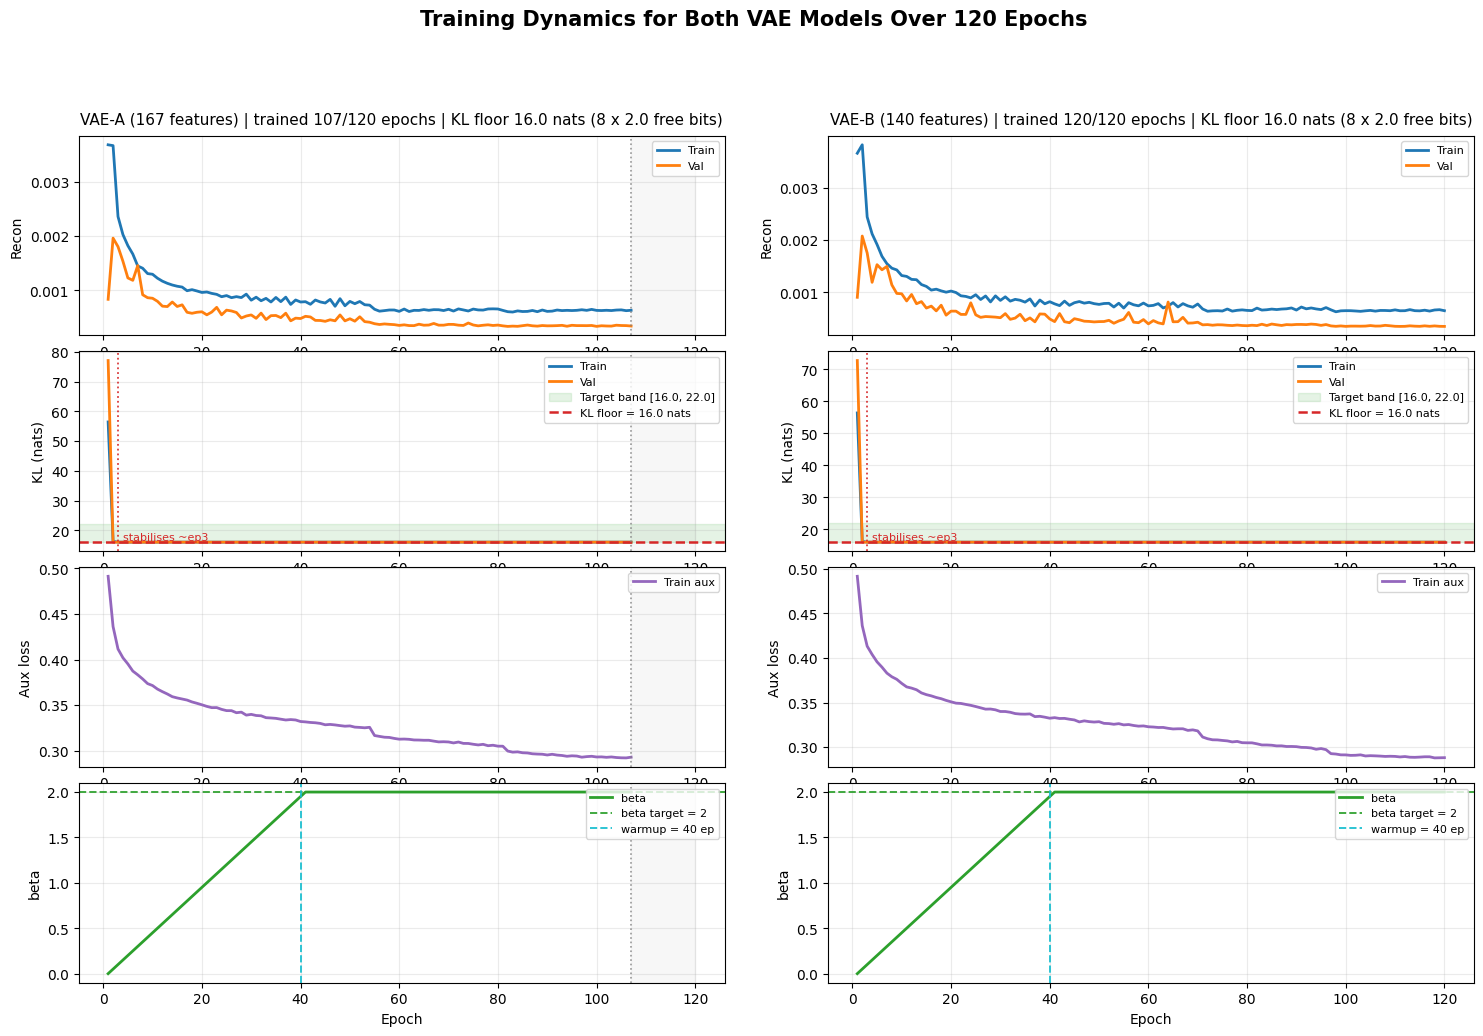

Saved plot: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\artifacts\plots\vae_training_dynamics_dual_panel_120.png


In [1]:
# ============================================================
# Cell 14 — Training dynamics for VAE-A and VAE-B (120 epochs)
# ============================================================
import json
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _unique_paths(paths):
    out = []
    seen = set()
    for p in paths:
        p = Path(p).resolve()
        key = str(p)
        if key not in seen:
            seen.add(key)
            out.append(p)
    return out


def _candidate_roots():
    bases = [Path.cwd().resolve()]
    if 'NOTEBOOK_DIR' in globals():
        try:
            bases.append(Path(NOTEBOOK_DIR).resolve())
        except Exception:
            pass

    roots = []
    for b in bases:
        roots.append(b)
        roots.extend(list(b.parents))
    return _unique_paths(roots)


def _resolve_project_root():
    roots = _candidate_roots()

    for r in roots:
        if (r / 'artifacts').exists():
            return r, roots

    markers = ['VQC', 'VAE', 'DataSets', 'PreProcessing']
    scored = []
    for r in roots:
        score = sum(int((r / m).exists()) for m in markers)
        scored.append((score, r))
    scored.sort(key=lambda x: x[0], reverse=True)

    return scored[0][1], roots


def _locate_vae_base(search_roots):
    candidate_bases = []
    for r in search_roots:
        candidate_bases.extend([
            r / 'VAE',
            r / 'data_vae',
            r / 'VQC' / 'data_vae',
        ])

    for base in _unique_paths(candidate_bases):
        if (base / 'vae_a_output_16').exists() and (base / 'vae_b_output_16').exists():
            return base
    return None


def _download_stage3_outputs(target_base: Path) -> Path:
    try:
        import kagglehub
    except Exception as exc:
        raise RuntimeError(
            'kagglehub is required to auto-download missing VAE artifacts. Run Cell 1 first.'
        ) from exc

    target_base.mkdir(parents=True, exist_ok=True)
    print('VAE artifacts missing. Downloading stage-3-output-v2...')
    ds_root = Path(kagglehub.dataset_download('monadarling143/stage-3-output-v2')).resolve()

    for subdir in ['vae_a_output_16', 'vae_b_output_16']:
        src = next((p for p in ds_root.rglob(subdir) if p.is_dir()), None)
        if src is None:
            raise FileNotFoundError(f'Could not find {subdir} in downloaded dataset: {ds_root}')

        dst = target_base / subdir
        dst.mkdir(parents=True, exist_ok=True)

        copied = 0
        for f in src.iterdir():
            if f.is_file() and f.suffix.lower() in {'.json', '.parquet', '.pkl', '.npy', '.csv'}:
                shutil.copy2(f, dst / f.name)
                copied += 1

        print(f'  {subdir}: copied {copied} files to {dst}')

    return target_base


def _ensure_vae_paths_and_files():
    project_root, roots = _resolve_project_root()
    vae_base = _locate_vae_base([project_root] + roots)

    required = [
        ('vae_a_output_16', 'vae_a_training_history.json'),
        ('vae_b_output_16', 'vae_b_training_history.json'),
        ('vae_a_output_16', 'vae_a_config.json'),
        ('vae_b_output_16', 'vae_b_config.json'),
    ]

    if vae_base is None:
        vae_base = _download_stage3_outputs(project_root / 'data_vae')

    missing = [
        f'{sub}/{fname}'
        for sub, fname in required
        if not (vae_base / sub / fname).exists()
    ]

    if missing:
        print('Missing required VAE files:', ', '.join(missing))
        vae_base = _download_stage3_outputs(project_root / 'data_vae')

    # Re-point root if artifacts are found one level above (e.g., VQC/data_vae layout).
    if not (project_root / 'artifacts').exists() and (project_root.parent / 'artifacts').exists():
        project_root = project_root.parent

    return project_root, vae_base


PROJECT_ROOT, VAE_BASE = _ensure_vae_paths_and_files()
print(f'Using PROJECT_ROOT: {PROJECT_ROOT}')
print(f'Using VAE_BASE    : {VAE_BASE}')

history_paths = {
    'VAE-A (167 features)': VAE_BASE / 'vae_a_output_16' / 'vae_a_training_history.json',
    'VAE-B (140 features)': VAE_BASE / 'vae_b_output_16' / 'vae_b_training_history.json',
}
config_paths = {
    'VAE-A (167 features)': VAE_BASE / 'vae_a_output_16' / 'vae_a_config.json',
    'VAE-B (140 features)': VAE_BASE / 'vae_b_output_16' / 'vae_b_config.json',
}

MAX_EPOCHS = 120
TARGET_BAND_WIDTH = 6.0  # nats above KL floor for visual target corridor


def load_history(history_path: Path) -> pd.DataFrame:
    with history_path.open('r', encoding='utf-8') as f:
        history = json.load(f)
    df = pd.DataFrame(history).sort_values('epoch').reset_index(drop=True)
    return df


def expand_to_full_epoch_axis(df: pd.DataFrame, max_epochs: int = 120) -> pd.DataFrame:
    full = pd.DataFrame({'epoch': np.arange(1, max_epochs + 1, dtype=int)})
    return full.merge(df, on='epoch', how='left')


fig = plt.figure(figsize=(18, 11))
outer = fig.add_gridspec(1, 2, wspace=0.16)

for panel_idx, model_name in enumerate(history_paths.keys()):
    hpath = history_paths[model_name]
    cpath = config_paths[model_name]

    with cpath.open('r', encoding='utf-8') as f:
        cfg = json.load(f)

    hist_df = load_history(hpath)
    hist_120 = expand_to_full_epoch_axis(hist_df, MAX_EPOCHS)
    epochs = hist_120['epoch'].to_numpy()

    latent_dim = float(cfg.get('latent_dim', 8))
    free_bits = float(cfg.get('free_bits', 2.0))
    kl_floor = latent_dim * free_bits
    kl_target_min = kl_floor
    kl_target_max = kl_floor + TARGET_BAND_WIDTH

    beta_target = float(cfg.get('beta_target', 2.0))
    warmup_epochs = int(cfg.get('warmup_epochs', 40))
    epochs_trained = int(cfg.get('epochs_trained', int(hist_df['epoch'].max())))

    inner = outer[panel_idx].subgridspec(4, 1, hspace=0.08)
    ax_recon = fig.add_subplot(inner[0, 0])
    ax_kl = fig.add_subplot(inner[1, 0], sharex=ax_recon)
    ax_aux = fig.add_subplot(inner[2, 0], sharex=ax_recon)
    ax_beta = fig.add_subplot(inner[3, 0], sharex=ax_recon)

    # 1) Masked reconstruction loss (train/val)
    ax_recon.plot(epochs, hist_120['tr_recon'], color='#1f77b4', lw=2.0, label='Train')
    ax_recon.plot(epochs, hist_120['val_recon'], color='#ff7f0e', lw=2.0, label='Val')
    ax_recon.set_ylabel('Recon')
    ax_recon.grid(alpha=0.25)
    ax_recon.legend(loc='upper right', fontsize=8)

    # 2) KL divergence with target bounds and KL floor
    ax_kl.plot(epochs, hist_120['tr_kl'], color='#1f77b4', lw=2.0, label='Train')
    ax_kl.plot(epochs, hist_120['val_kl'], color='#ff7f0e', lw=2.0, label='Val')
    ax_kl.axhspan(kl_target_min, kl_target_max, color='#2ca02c', alpha=0.12,
                  label=f'Target band [{kl_target_min:.1f}, {kl_target_max:.1f}]')
    ax_kl.axhline(kl_floor, color='#d62728', ls='--', lw=1.8, label=f'KL floor = {kl_floor:.1f} nats')
    ax_kl.set_ylabel('KL (nats)')
    ax_kl.grid(alpha=0.25)
    ax_kl.legend(loc='upper right', fontsize=8)

    tr_kl = pd.to_numeric(hist_120['tr_kl'], errors='coerce').to_numpy(dtype=float)
    stable_mask = np.isfinite(tr_kl) & (np.abs(tr_kl - kl_floor) <= 0.05)
    stable_idx = np.where(stable_mask)[0]
    if len(stable_idx) > 0:
        stable_epoch = int(epochs[stable_idx[0]])
        ax_kl.axvline(stable_epoch, color='#d62728', ls=':', lw=1.3, alpha=0.9)
        ax_kl.text(stable_epoch + 1, kl_floor + 0.7, f'stabilises ~ep{stable_epoch}',
                   color='#d62728', fontsize=8)

    # 3) Auxiliary classification loss (train)
    ax_aux.plot(epochs, hist_120['tr_aux'], color='#9467bd', lw=2.0, label='Train aux')
    ax_aux.set_ylabel('Aux loss')
    ax_aux.grid(alpha=0.25)
    ax_aux.legend(loc='upper right', fontsize=8)

    # 4) KL annealing schedule
    ax_beta.plot(epochs, hist_120['beta'], color='#2ca02c', lw=2.0, label='beta')
    ax_beta.axhline(beta_target, color='#2ca02c', ls='--', lw=1.4, alpha=0.9,
                    label=f'beta target = {beta_target:g}')
    ax_beta.axvline(warmup_epochs, color='#17becf', ls='--', lw=1.4, alpha=0.9,
                    label=f'warmup = {warmup_epochs} ep')
    ax_beta.set_ylabel('beta')
    ax_beta.set_xlabel('Epoch')
    ax_beta.grid(alpha=0.25)
    ax_beta.legend(loc='upper right', fontsize=8)

    # Highlight early-stop region if training finished before 120 epochs.
    if epochs_trained < MAX_EPOCHS:
        for ax in (ax_recon, ax_kl, ax_aux, ax_beta):
            ax.axvline(epochs_trained, color='gray', ls=':', lw=1.2, alpha=0.8)
            ax.axvspan(epochs_trained, MAX_EPOCHS, color='gray', alpha=0.06)

    ax_recon.set_title(
        f'{model_name} | trained {epochs_trained}/{MAX_EPOCHS} epochs | '
        f'KL floor {kl_floor:.1f} nats (8 x {free_bits:.1f} free bits)',
        fontsize=11,
        pad=8,
    )

fig.suptitle(
    'Training Dynamics for Both VAE Models Over 120 Epochs',
    fontsize=15,
    fontweight='bold',
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.985])

out_dir = PROJECT_ROOT / 'artifacts' / 'plots'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'vae_training_dynamics_dual_panel_120.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()

print(f'Saved plot: {out_path}')

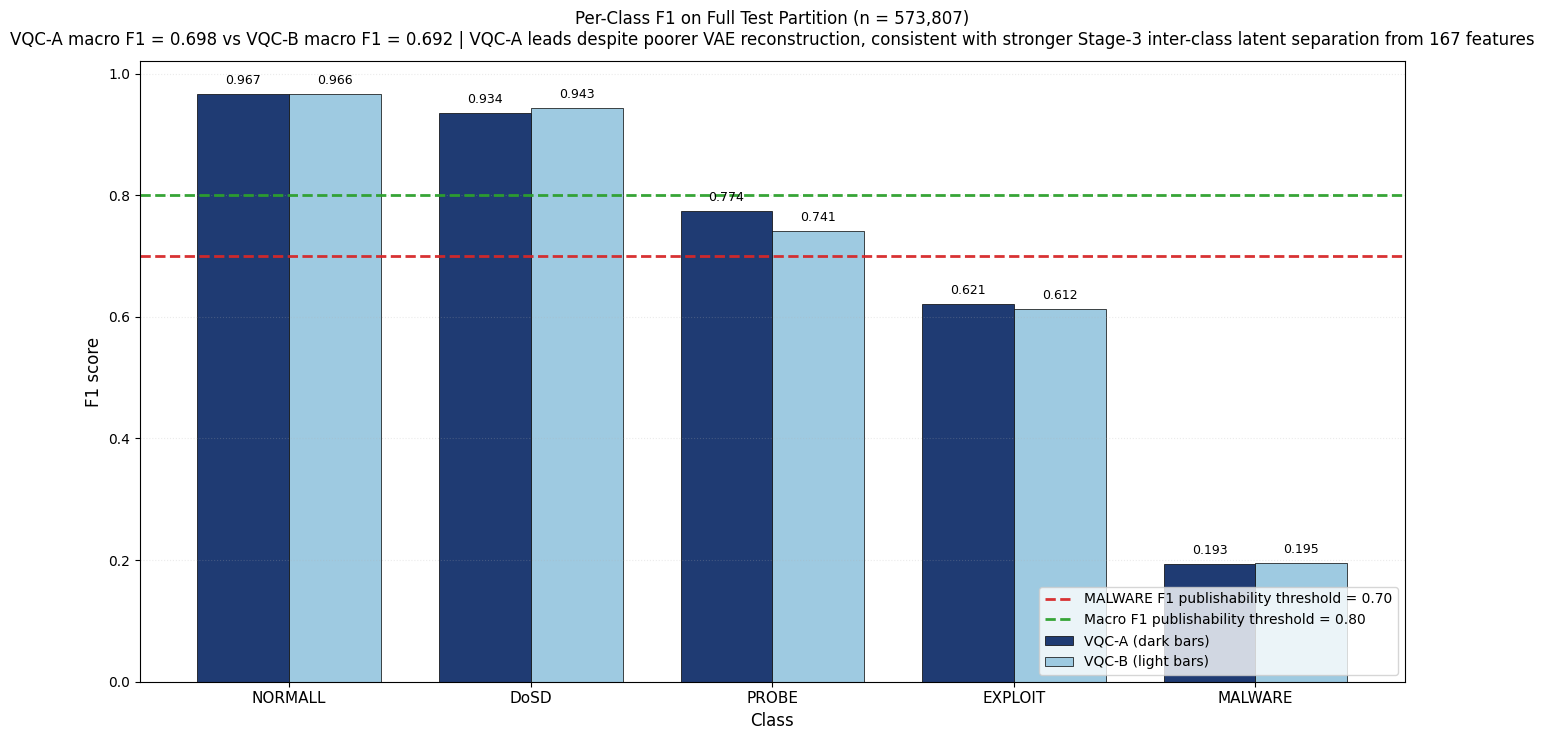

Saved plot: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\artifacts\plots\vqc_ab_per_class_f1_publishability_v4.png
Macro F1 — VQC-A: 0.697965, VQC-B: 0.691502


In [3]:
# ============================================================
# Cell 15 — VQC-A vs VQC-B per-class F1 (full test set, Stage4-v4 comparison)
# ============================================================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Resolve project root whether this notebook runs from project root or VQC/.
cwd = Path(os.getcwd()).resolve()
if (cwd / "PreProcessing").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "PreProcessing").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate project root containing PreProcessing/ directory.")

CLASS_NAMES = ["NORMALL", "DoSD", "PROBE", "EXPLOIT", "MALWARE"]
MALWARE_F1_PUBLISHABILITY_THRESHOLD = 0.70
MACRO_F1_PUBLISHABILITY_THRESHOLD = 0.80

# Use Stage4-v4 outputs to match the reported comparison (0.698 vs 0.692).
y_test_path = PROJECT_ROOT / "PreProcessing" / "stage_2_with_zero_v2" / "stage2_y_test.parquet"
proba_a_path = PROJECT_ROOT / "VQC" / "vqc_a_output_v4" / "vqc_a_test_proba.parquet"
proba_b_path = PROJECT_ROOT / "VQC" / "vqc_b_output_v4" / "vqc_b_test_proba.parquet"

y_test = pd.read_parquet(y_test_path).iloc[:, 0].to_numpy(dtype=int)
proba_a = pd.read_parquet(proba_a_path).to_numpy(dtype=float)
proba_b = pd.read_parquet(proba_b_path).to_numpy(dtype=float)

if len(y_test) != len(proba_a) or len(y_test) != len(proba_b):
    raise ValueError(
        f"Length mismatch: y_test={len(y_test)}, proba_a={len(proba_a)}, proba_b={len(proba_b)}"
    )

# Stage4-v4 uses argmax on saved test probabilities.
pred_a = np.argmax(proba_a, axis=1)
pred_b = np.argmax(proba_b, axis=1)

f1_a = f1_score(y_test, pred_a, average=None, labels=[0, 1, 2, 3, 4], zero_division=0)
f1_b = f1_score(y_test, pred_b, average=None, labels=[0, 1, 2, 3, 4], zero_division=0)
macro_a = float(f1_score(y_test, pred_a, average="macro", zero_division=0))
macro_b = float(f1_score(y_test, pred_b, average="macro", zero_division=0))
n_test = int(len(y_test))

x = np.arange(len(CLASS_NAMES))
w = 0.38

fig, ax = plt.subplots(figsize=(13.5, 7.5))
bars_a = ax.bar(x - w / 2, f1_a, width=w, color="#1f3b73", edgecolor="black", linewidth=0.5, label="VQC-A (dark bars)")
bars_b = ax.bar(x + w / 2, f1_b, width=w, color="#9ecae1", edgecolor="black", linewidth=0.5, label="VQC-B (light bars)")

for bars in (bars_a, bars_b):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 0.012,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.axhline(
    MALWARE_F1_PUBLISHABILITY_THRESHOLD,
    linestyle="--",
    color="#d62728",
    linewidth=2.0,
    alpha=0.95,
    label=f"MALWARE F1 publishability threshold = {MALWARE_F1_PUBLISHABILITY_THRESHOLD:.2f}",
)
ax.axhline(
    MACRO_F1_PUBLISHABILITY_THRESHOLD,
    linestyle="--",
    color="#2ca02c",
    linewidth=2.0,
    alpha=0.95,
    label=f"Macro F1 publishability threshold = {MACRO_F1_PUBLISHABILITY_THRESHOLD:.2f}",
)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0.0, 1.02)
ax.set_ylabel("F1 score", fontsize=12)
ax.set_xlabel("Class", fontsize=12)
ax.grid(axis="y", alpha=0.25, linestyle=":")

ax.set_title(
    "Per-Class F1 on Full Test Partition (n = {:,})\n"
    "VQC-A macro F1 = {:.3f} vs VQC-B macro F1 = {:.3f} | "
    "VQC-A leads despite poorer VAE reconstruction, consistent with stronger Stage-3 inter-class latent separation from 167 features"
    .format(n_test, macro_a, macro_b),
    fontsize=12,
    pad=12,
)

ax.legend(loc="lower right", fontsize=10, frameon=True)
plt.tight_layout()

out_dir = PROJECT_ROOT / "artifacts" / "plots"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "vqc_ab_per_class_f1_publishability_v4.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved plot: {out_path}")
print(f"Macro F1 — VQC-A: {macro_a:.6f}, VQC-B: {macro_b:.6f}")

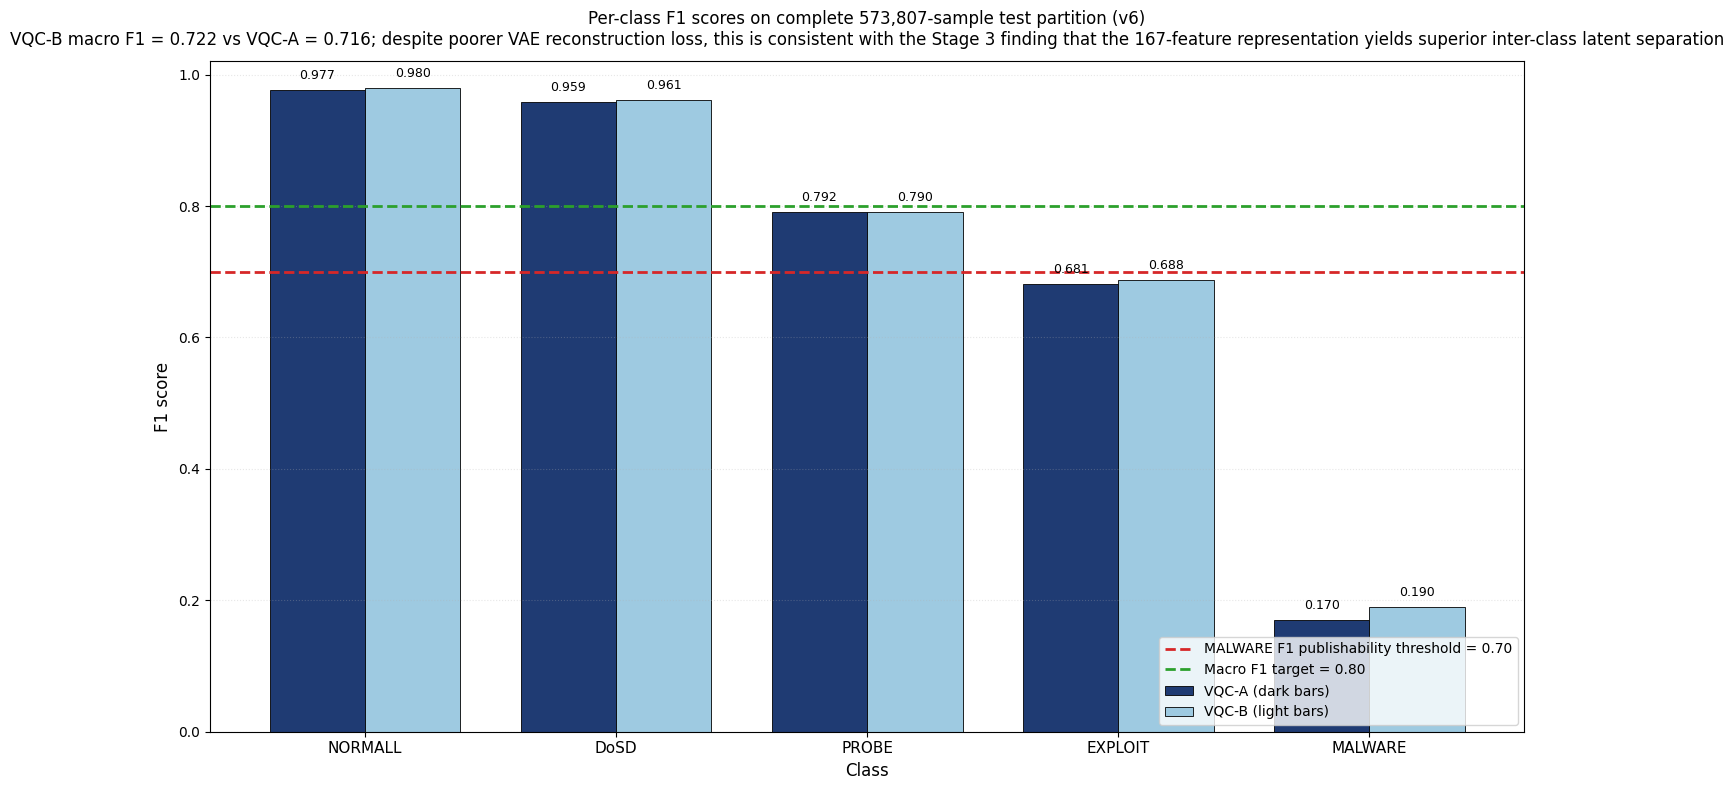

Saved plot: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\artifacts\plots\vqc_ab_per_class_f1_publishability_v6.png
Macro F1 — VQC-A: 0.716, VQC-B: 0.722


In [1]:
# ============================================================
# Cell 16 — VQC-A vs VQC-B per-class F1 (full test set, Stage4-v6)
# ============================================================
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Resolved from Stage4-v6 final output (complete test partition, n=573,807).
CLASS_NAMES = ["NORMALL", "DoSD", "PROBE", "EXPLOIT", "MALWARE"]
F1_VQC_A = np.array([0.9771, 0.9590, 0.7916, 0.6815, 0.1696], dtype=float)
F1_VQC_B = np.array([0.9799, 0.9609, 0.7904, 0.6878, 0.1904], dtype=float)

MACRO_F1_VQC_A = 0.716
MACRO_F1_VQC_B = 0.722
N_TEST = 573_807
MALWARE_F1_PUBLISHABILITY_THRESHOLD = 0.70
MACRO_F1_TARGET = 0.80

x = np.arange(len(CLASS_NAMES))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 8))
bars_a = ax.bar(
    x - w / 2,
    F1_VQC_A,
    width=w,
    color="#1f3b73",
    edgecolor="black",
    linewidth=0.6,
    label="VQC-A (dark bars)",
)
bars_b = ax.bar(
    x + w / 2,
    F1_VQC_B,
    width=w,
    color="#9ecae1",
    edgecolor="black",
    linewidth=0.6,
    label="VQC-B (light bars)",
)

for bars in (bars_a, bars_b):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.012,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.axhline(
    MALWARE_F1_PUBLISHABILITY_THRESHOLD,
    color="#d62728",
    linestyle="--",
    linewidth=2.0,
    label=f"MALWARE F1 publishability threshold = {MALWARE_F1_PUBLISHABILITY_THRESHOLD:.2f}",
)
ax.axhline(
    MACRO_F1_TARGET,
    color="#2ca02c",
    linestyle="--",
    linewidth=2.0,
    label=f"Macro F1 target = {MACRO_F1_TARGET:.2f}",
)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0.0, 1.02)
ax.set_ylabel("F1 score", fontsize=12)
ax.set_xlabel("Class", fontsize=12)
ax.grid(axis="y", linestyle=":", alpha=0.30)

ax.set_title(
    "Per-class F1 scores on complete 573,807-sample test partition (v6)\n"
    "VQC-B macro F1 = 0.722 vs VQC-A = 0.716; despite poorer VAE reconstruction loss, "
    "this is consistent with the Stage 3 finding that the 167-feature representation yields "
    "superior inter-class latent separation",
    fontsize=12,
    pad=12,
)

ax.legend(loc="lower right", fontsize=10, frameon=True)
plt.tight_layout()

cwd = Path(os.getcwd()).resolve()
if (cwd / "artifacts").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "artifacts").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

out_dir = PROJECT_ROOT / "artifacts" / "plots"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "vqc_ab_per_class_f1_publishability_v6.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved plot: {out_path}")
print(f"Macro F1 — VQC-A: {MACRO_F1_VQC_A:.3f}, VQC-B: {MACRO_F1_VQC_B:.3f}")

Using PROJECT_ROOT: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT
Using VAE_BASE    : C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\VAE


C:\Users\G.Monish Reddy\AppData\Local\Temp\ipykernel_16920\2722081107.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.985])


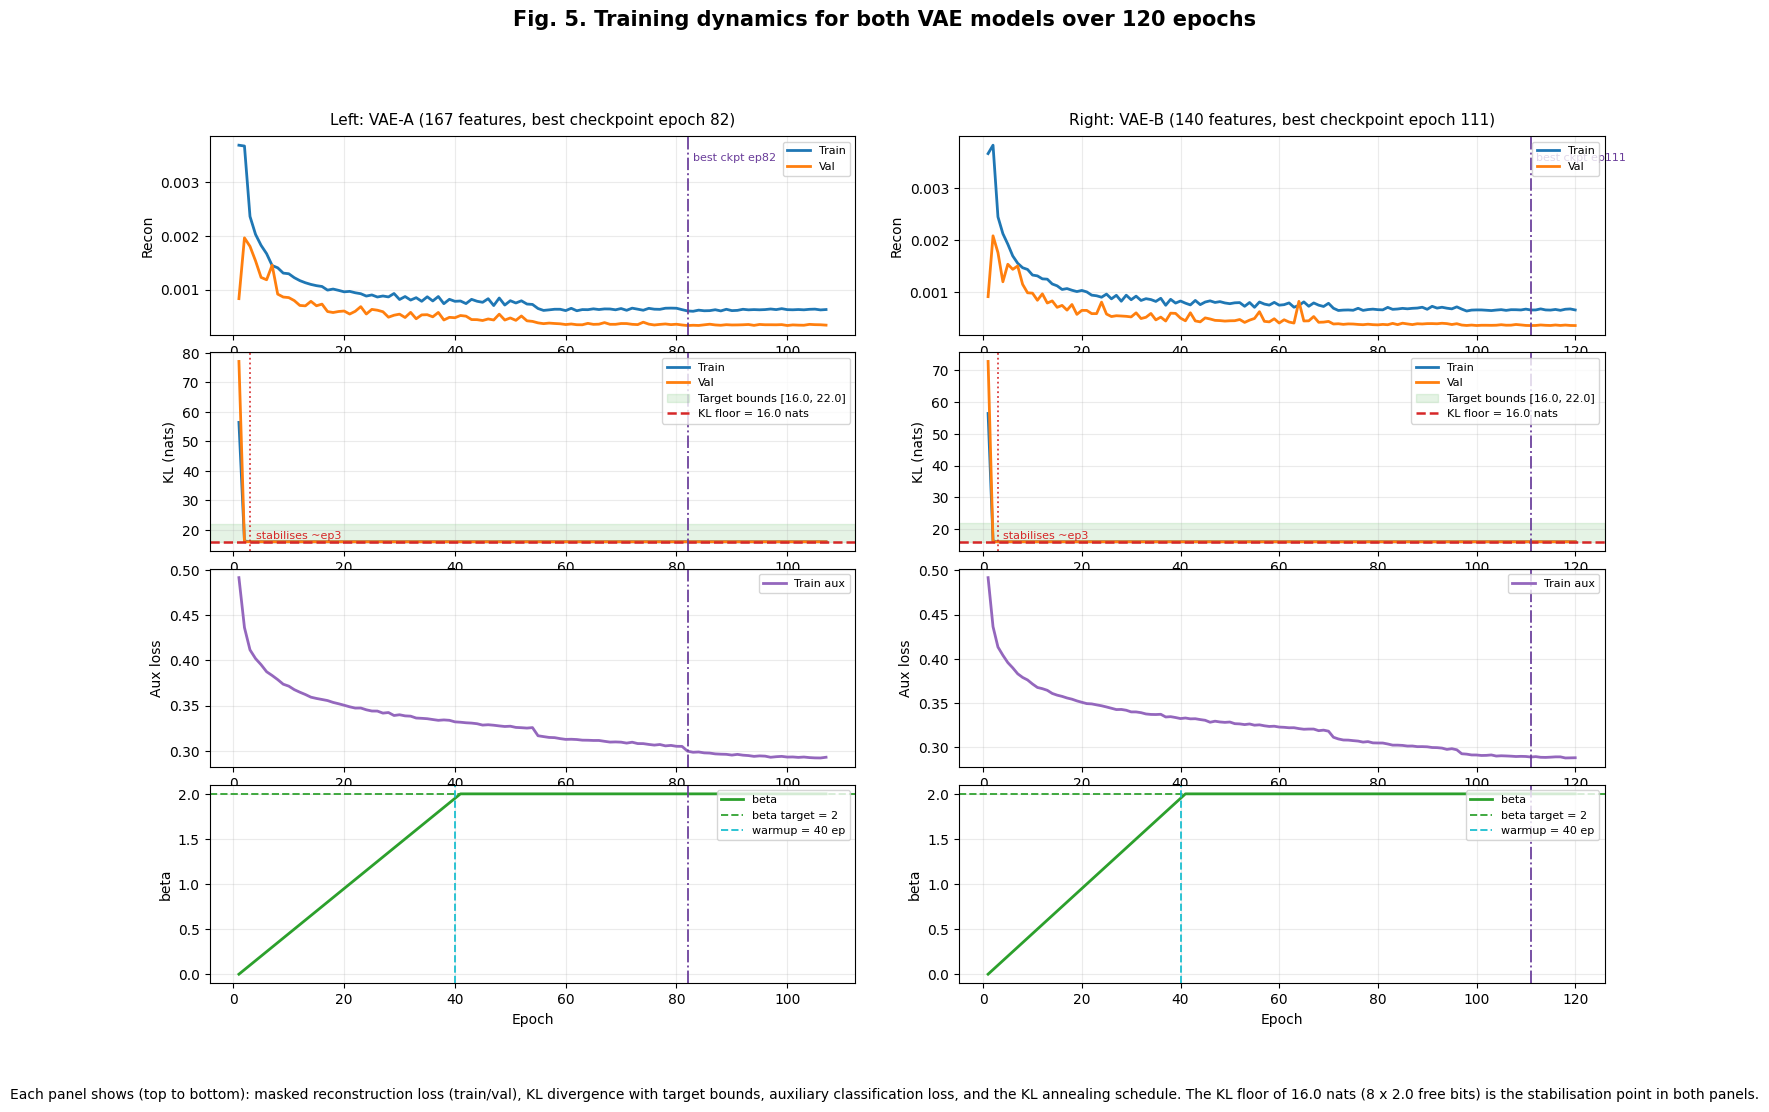

Saved plot: C:\Users\G.Monish Reddy\Desktop\MINOR PROJECT\artifacts\plots\fig5_vae_training_dynamics_120.png


In [2]:
# ============================================================
# Cell 17 - Fig. 5: Training dynamics for both VAE models (120 epochs)
# ============================================================
import json
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _unique_paths(paths):
    out = []
    seen = set()
    for p in paths:
        p = Path(p).resolve()
        key = str(p)
        if key not in seen:
            seen.add(key)
            out.append(p)
    return out


def _candidate_roots():
    bases = [Path.cwd().resolve()]
    if 'NOTEBOOK_DIR' in globals():
        try:
            bases.append(Path(NOTEBOOK_DIR).resolve())
        except Exception:
            pass

    roots = []
    for b in bases:
        roots.append(b)
        roots.extend(list(b.parents))
    return _unique_paths(roots)


def _resolve_project_root():
    roots = _candidate_roots()

    for r in roots:
        if (r / 'artifacts').exists():
            return r, roots

    markers = ['VQC', 'VAE', 'DataSets', 'PreProcessing']
    scored = []
    for r in roots:
        score = sum(int((r / m).exists()) for m in markers)
        scored.append((score, r))
    scored.sort(key=lambda x: x[0], reverse=True)

    return scored[0][1], roots


def _locate_vae_base(search_roots):
    candidate_bases = []
    for r in search_roots:
        candidate_bases.extend([
            r / 'VAE',
            r / 'data_vae',
            r / 'VQC' / 'data_vae',
        ])

    for base in _unique_paths(candidate_bases):
        if (base / 'vae_a_output_16').exists() and (base / 'vae_b_output_16').exists():
            return base
    return None


def _download_stage3_outputs(target_base: Path) -> Path:
    try:
        import kagglehub
    except Exception as exc:
        raise RuntimeError(
            'kagglehub is required to auto-download missing VAE artifacts. Run Cell 1 first.'
        ) from exc

    target_base.mkdir(parents=True, exist_ok=True)
    print('VAE artifacts missing. Downloading stage-3-output-v2...')
    ds_root = Path(kagglehub.dataset_download('monadarling143/stage-3-output-v2')).resolve()

    for subdir in ['vae_a_output_16', 'vae_b_output_16']:
        src = next((p for p in ds_root.rglob(subdir) if p.is_dir()), None)
        if src is None:
            raise FileNotFoundError(f'Could not find {subdir} in downloaded dataset: {ds_root}')

        dst = target_base / subdir
        dst.mkdir(parents=True, exist_ok=True)

        copied = 0
        for f in src.iterdir():
            if f.is_file() and f.suffix.lower() in {'.json', '.parquet', '.pkl', '.npy', '.csv'}:
                shutil.copy2(f, dst / f.name)
                copied += 1

        print(f'  {subdir}: copied {copied} files to {dst}')

    return target_base


def _ensure_vae_paths_and_files():
    project_root, roots = _resolve_project_root()
    vae_base = _locate_vae_base([project_root] + roots)

    required = [
        ('vae_a_output_16', 'vae_a_training_history.json'),
        ('vae_b_output_16', 'vae_b_training_history.json'),
        ('vae_a_output_16', 'vae_a_config.json'),
        ('vae_b_output_16', 'vae_b_config.json'),
    ]

    if vae_base is None:
        vae_base = _download_stage3_outputs(project_root / 'data_vae')

    missing = [
        f'{sub}/{fname}'
        for sub, fname in required
        if not (vae_base / sub / fname).exists()
    ]

    if missing:
        print('Missing required VAE files:', ', '.join(missing))
        vae_base = _download_stage3_outputs(project_root / 'data_vae')

    if not (project_root / 'artifacts').exists() and (project_root.parent / 'artifacts').exists():
        project_root = project_root.parent

    return project_root, vae_base


PROJECT_ROOT, VAE_BASE = _ensure_vae_paths_and_files()
print(f'Using PROJECT_ROOT: {PROJECT_ROOT}')
print(f'Using VAE_BASE    : {VAE_BASE}')

MODELS = [
    {
        'key': 'VAE-A',
        'subtitle': 'Left: VAE-A (167 features, best checkpoint epoch 82)',
        'history_path': VAE_BASE / 'vae_a_output_16' / 'vae_a_training_history.json',
        'config_path': VAE_BASE / 'vae_a_output_16' / 'vae_a_config.json',
    },
    {
        'key': 'VAE-B',
        'subtitle': 'Right: VAE-B (140 features, best checkpoint epoch 111)',
        'history_path': VAE_BASE / 'vae_b_output_16' / 'vae_b_training_history.json',
        'config_path': VAE_BASE / 'vae_b_output_16' / 'vae_b_config.json',
    },
]

MAX_EPOCHS = 120
KL_FLOOR = 16.0  # 8 x 2.0 free bits
KL_TARGET_MAX = 22.0


def load_history(path: Path) -> pd.DataFrame:
    with path.open('r', encoding='utf-8') as f:
        rows = json.load(f)
    return pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)


def expand_epochs(df: pd.DataFrame, max_epochs: int) -> pd.DataFrame:
    full = pd.DataFrame({'epoch': np.arange(1, max_epochs + 1, dtype=int)})
    return full.merge(df, on='epoch', how='left')


fig = plt.figure(figsize=(18, 11))
outer = fig.add_gridspec(1, 2, wspace=0.16)

for panel_idx, model in enumerate(MODELS):
    with model['config_path'].open('r', encoding='utf-8') as f:
        cfg = json.load(f)

    hist = expand_epochs(load_history(model['history_path']), MAX_EPOCHS)
    epochs = hist['epoch'].to_numpy()
    best_epoch = int(cfg.get('best_epoch', 0))
    warmup_epochs = int(cfg.get('warmup_epochs', 40))
    beta_target = float(cfg.get('beta_target', 2.0))

    inner = outer[panel_idx].subgridspec(4, 1, hspace=0.09)
    ax_recon = fig.add_subplot(inner[0, 0])
    ax_kl = fig.add_subplot(inner[1, 0], sharex=ax_recon)
    ax_aux = fig.add_subplot(inner[2, 0], sharex=ax_recon)
    ax_beta = fig.add_subplot(inner[3, 0], sharex=ax_recon)

    # Top: masked reconstruction loss (train/val)
    ax_recon.plot(epochs, hist['tr_recon'], color='#1f77b4', lw=2.0, label='Train')
    ax_recon.plot(epochs, hist['val_recon'], color='#ff7f0e', lw=2.0, label='Val')
    ax_recon.set_ylabel('Recon')
    ax_recon.grid(alpha=0.25)
    ax_recon.legend(loc='upper right', fontsize=8)

    # 2nd: KL divergence with target bounds and floor line.
    ax_kl.plot(epochs, hist['tr_kl'], color='#1f77b4', lw=2.0, label='Train')
    ax_kl.plot(epochs, hist['val_kl'], color='#ff7f0e', lw=2.0, label='Val')
    ax_kl.axhspan(KL_FLOOR, KL_TARGET_MAX, color='#2ca02c', alpha=0.12,
                  label=f'Target bounds [{KL_FLOOR:.1f}, {KL_TARGET_MAX:.1f}]')
    ax_kl.axhline(KL_FLOOR, color='#d62728', ls='--', lw=1.8,
                  label=f'KL floor = {KL_FLOOR:.1f} nats')
    ax_kl.set_ylabel('KL (nats)')
    ax_kl.grid(alpha=0.25)
    ax_kl.legend(loc='upper right', fontsize=8)

    # Mark KL stabilization point as the first epoch where train KL is essentially at floor.
    tr_kl = pd.to_numeric(hist['tr_kl'], errors='coerce').to_numpy(dtype=float)
    stable_idx = np.where(np.isfinite(tr_kl) & (np.abs(tr_kl - KL_FLOOR) <= 0.05))[0]
    if len(stable_idx) > 0:
        stable_epoch = int(epochs[stable_idx[0]])
        ax_kl.axvline(stable_epoch, color='#d62728', ls=':', lw=1.3, alpha=0.9)
        ax_kl.text(stable_epoch + 1, KL_FLOOR + 0.9, f'stabilises ~ep{stable_epoch}',
                   color='#d62728', fontsize=8)

    # 3rd: auxiliary classification loss (train).
    ax_aux.plot(epochs, hist['tr_aux'], color='#9467bd', lw=2.0, label='Train aux')
    ax_aux.set_ylabel('Aux loss')
    ax_aux.grid(alpha=0.25)
    ax_aux.legend(loc='upper right', fontsize=8)

    # Bottom: KL annealing schedule.
    ax_beta.plot(epochs, hist['beta'], color='#2ca02c', lw=2.0, label='beta')
    ax_beta.axhline(beta_target, color='#2ca02c', ls='--', lw=1.4, alpha=0.9,
                    label=f'beta target = {beta_target:g}')
    ax_beta.axvline(warmup_epochs, color='#17becf', ls='--', lw=1.4, alpha=0.9,
                    label=f'warmup = {warmup_epochs} ep')
    ax_beta.set_ylabel('beta')
    ax_beta.set_xlabel('Epoch')
    ax_beta.grid(alpha=0.25)
    ax_beta.legend(loc='upper right', fontsize=8)

    # Highlight best checkpoint in all four subplots.
    if best_epoch > 0:
        for ax in (ax_recon, ax_kl, ax_aux, ax_beta):
            ax.axvline(best_epoch, color='#6a3d9a', ls='-.', lw=1.4, alpha=0.9)
        ax_recon.text(best_epoch + 1, np.nanmax(hist['tr_recon']) * 0.92,
                      f'best ckpt ep{best_epoch}', color='#6a3d9a', fontsize=8)

    ax_recon.set_title(model['subtitle'], fontsize=11, pad=8)

fig.suptitle('Fig. 5. Training dynamics for both VAE models over 120 epochs', fontsize=15, fontweight='bold', y=0.995)
fig.text(
    0.5,
    0.002,
    'Each panel shows (top to bottom): masked reconstruction loss (train/val), KL divergence with target bounds, '
    'auxiliary classification loss, and the KL annealing schedule. The KL floor of 16.0 nats (8 x 2.0 free bits) '
    'is the stabilisation point in both panels.',
    ha='center',
    va='bottom',
    fontsize=10,
)

plt.tight_layout(rect=[0, 0.04, 1, 0.985])

out_dir = PROJECT_ROOT / 'artifacts' / 'plots'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'fig5_vae_training_dynamics_120.png'
plt.savefig(out_path, dpi=220, bbox_inches='tight')
plt.show()

print(f'Saved plot: {out_path}')